# FedCircuitNet - client-count sweep (RouteNetGroupNorm)

K = 5 / 10 / 50 / 100 are read from the `*_sweep_clients` Aim experiments (`sweep_clients_config/`, `run_sweep_clients_exp.sh`). K = 20 is the existing `config/fedavg_*_<scheme>_groupnorm.yaml` runs, read from the basic `fedavg_drc_{train,test,augmented_metrics}` experiments: same model, 50 % participation and 40,000-step budget, so they are the K = 20 point of the sweep.

## Setup and helpers

In [1]:
# Registers the PNG formatter up front; without it the first plotting cell
# renders its figures as text under the pinned matplotlib 3.7.
%matplotlib inline

import os
import re
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from aim import Repo
from aim.storage.context import Context

# Same ROC / PR-AUC code test_aim.py runs (verbatim port of the CircuitNet
# reference, see utils/__init__.py).
from utils.metrics import calculate_all, get_sorted_list, roc_prc

repo = Repo(path=os.getcwd())

# Experiment names set in sweep_clients_config/*.yaml (K = 5 / 10 / 50 / 100).
TRAIN_EXPERIMENT = 'fedavg_drc_train_sweep_clients'
TEST_EXPERIMENT = 'fedavg_drc_test_sweep_clients'
AUG_EXPERIMENT = 'fedavg_drc_augmented_metrics_sweep_clients'

SCHEMES = ['iid', 'dirichlet', 'kmeans', 'feature_hierarchical']

# Sweep run ID: the augmented-metrics Aim tag, and the work_dirs folder name
# (fedavg_<ID>) that train / test runs are recovered from.
SWEEP_ID = re.compile(r'^(?P<scheme>' + '|'.join(SCHEMES) + r')_groupnorm_c(?P<K>\d+)$')

# K = 20 is not in the sweep: it is the config/fedavg_{train,test,augmented_metrics}
# _<scheme>_groupnorm.yaml runs (m = 10, E = 20, T = 200: same 50 % participation
# and 40,000-step budget).  They are logged in the basic experiments next to the
# BatchNorm RouteNet runs and carry no _c<K> ID: train / test runs are matched by
# save folder (not named uniformly across schemes), augmented-metrics runs by
# their `tag:`.
BASE_K = 20
BASE_MODEL = 'RouteNetGroupNorm'
BASE_TRAIN_EXPERIMENT = 'fedavg_drc_train'
BASE_TEST_EXPERIMENT = 'fedavg_drc_test'
BASE_AUG_EXPERIMENT = 'fedavg_drc_augmented_metrics'
BASE_FOLDER = {'iid': 'fedavg_iid_gn', 'dirichlet': 'fedavg_dirichlet_gn',
               'kmeans': 'fedavg_kmeans_groupnorm',
               'feature_hierarchical': 'fedavg_feature_hierarchical_groupnorm'}
BASE_TAG = {s: f'{s}_groupnorm' for s in SCHEMES}
# Before 2026-09-14 the kmeans / feature_hierarchical configs trained into the
# same folders with T = 500 (and, briefly, m = 20); only runs with today's
# settings are the K = 20 point.
BASE_TRAIN_HPARAMS = {('partitioning', 'n_partitions'): BASE_K, ('strategy', 'round_clients'): 10,
                      ('strategy', 'local_epochs'): 20, ('training', 'num_rounds'): 200}

# Colour follows the entity, never its rank: one fixed categorical slot per
# scheme, plus a marker so identity never rests on colour alone ...
SCHEME_COLOR = {'iid': '#2a78d6', 'dirichlet': '#eb6834',
                'kmeans': '#1baf7a', 'feature_hierarchical': '#eda100'}
SCHEME_MARKER = {'iid': 'o', 'dirichlet': 's', 'kmeans': '^', 'feature_hierarchical': 'D'}
# ... and an ordinal light -> dark blue ramp when K is the series.
K_RAMP = ['#86b6ef', '#5598e7', '#256abf', '#184f95', '#0d366b']
# Categorical slots for nominal metadata values (design_name) in the
# partition-composition plots.
VALUE_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
INK, MUTED = '#0b0b0b', '#898781'

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#c3c2b7',
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'axes.axisbelow': True,
    'axes.titlesize': 10,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.6,
    'lines.linewidth': 1.6,
    'legend.frameon': False,
    'figure.dpi': 110,
})

In [2]:
def runs_of(experiment):
    query = (
        'run.active == False and run.archived == False '
        f'and run.experiment == "{experiment}"'
    )
    return [w.run for w in repo.query_runs(query=query, report_mode=0).iter_runs()]


def sweep_label(scheme, K):
    return BASE_TAG[scheme] if K == BASE_K else f'{scheme}_groupnorm_c{K}'


def save_folder(run, phase):
    hparams = run.get('hparams') or {}
    block = 'training' if phase == 'train' else 'evaluation'
    return os.path.basename(os.path.normpath((hparams.get(block) or {}).get('save_path') or ''))


def run_sweep_id(run, phase):
    # Augmented-metrics runs carry the ID as their Aim tag (`tag:` in the yaml).
    if phase == 'augmented_metrics':
        ids = [t for t in run.tags if SWEEP_ID.match(str(t))]
        return ids[0] if len(ids) == 1 else None
    # Train / test runs carry no tag: recover it from the save folder.
    folder = save_folder(run, phase)
    return folder[len('fedavg_'):] if folder.startswith('fedavg_') else None


def sweep_key(run, phase):
    match = SWEEP_ID.match(run_sweep_id(run, phase) or '')
    return (match['scheme'], int(match['K'])) if match else None


def base_key(run, phase):
    # (scheme, BASE_K) for a K = 20 run; None for the other runs sharing the
    # basic experiments (BatchNorm RouteNet, outdated settings).
    hparams = run.get('hparams') or {}
    if (hparams.get('model') or {}).get('type') != BASE_MODEL:
        return None
    if phase == 'train' and any((hparams.get(block) or {}).get(field) != value
                                for (block, field), value in BASE_TRAIN_HPARAMS.items()):
        return None
    if phase == 'augmented_metrics':
        tags = {str(t) for t in run.tags}
        schemes = [s for s in SCHEMES if BASE_TAG[s] in tags]
    else:
        schemes = [s for s in SCHEMES if BASE_FOLDER[s] == save_folder(run, phase)]
    return (schemes[0], BASE_K) if len(schemes) == 1 else None


def collect_runs(experiment, phase, key_of):
    # {(scheme, K): run} for one phase; on re-runs the latest run wins.
    found, ignored = defaultdict(list), 0
    for run in runs_of(experiment):
        key = key_of(run, phase)
        if key is None:
            ignored += 1
            continue
        found[key].append(run)
    out = {}
    for key, runs in found.items():
        runs.sort(key=lambda r: r.creation_time)
        if len(runs) > 1:
            print(f'[{phase}] {sweep_label(*key)}: {len(runs)} runs, keeping the latest ({runs[-1].hash})')
        out[key] = runs[-1]
    if ignored:
        print(f'[{phase}] ignored {ignored} run(s) in {experiment} outside the sweep')
    return out


def collect_phase(phase, sweep_experiment, base_experiment):
    # Sweep runs plus the K = 20 runs; a sweep run at K = 20 would take precedence.
    runs = collect_runs(base_experiment, phase, base_key)
    sweep = collect_runs(sweep_experiment, phase, sweep_key)
    for key in runs.keys() & sweep.keys():
        print(f'[{phase}] K = {key[1]} {key[0]} in both {sweep_experiment} and {base_experiment}: '
              'keeping the sweep run')
    runs.update(sweep)
    return runs


def ordered(runs):
    # Yield (scheme, K, run) grouped by K, schemes in fixed order.
    for K in KS:
        for scheme in SCHEMES:
            if (scheme, K) in runs:
                yield scheme, K, runs[(scheme, K)]


def round_clients(K):
    # m actually used at size K, read from the train hparams rather than assumed.
    ms = {((r.get('hparams') or {}).get('strategy') or {}).get('round_clients')
          for (_, k), r in train_runs.items() if k == K}
    ms.discard(None)
    return ms.pop() if len(ms) == 1 else None


def size_header(K):
    m = round_clients(K)
    part = f'm = {m} per round ({100 * m / K:.0f} % participation)' if m else 'm not logged'
    display(Markdown(f'### K = {K} clients - {part}'))


def metric_series(run, name, context=None):
    # (steps, values) of a tracked metric, sorted by step; empty if missing.
    metric = run.get_metric(name, context=Context(context or {}))
    if metric is None:
        return np.array([]), np.array([])
    steps, (vals,) = metric.data.view('val').numpy()
    order = np.argsort(steps, kind='stable')
    return steps[order], np.asarray(vals, dtype=float)[order]


def last_value(run, name, context=None):
    _, vals = metric_series(run, name, context)
    return float(vals[-1]) if vals.size else np.nan


def per_sample(run, name):
    return metric_series(run, name, {'subset': 'test', 'aggregation': 'distribution'})[1]


def mark_missing(ax, title, text='not run'):
    ax.set_title(title)
    ax.text(0.5, 0.5, text, ha='center', va='center', transform=ax.transAxes, color=MUTED)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)


def scheme_legend(ax, schemes=SCHEMES, **kw):
    handles = [plt.Line2D([], [], color=SCHEME_COLOR[s], marker=SCHEME_MARKER[s], label=s) for s in schemes]
    ax.legend(handles=handles, fontsize=8, **kw)


def scheme_box_legend(fig):
    # One legend for a whole figure of grouped box plots, below the panels.
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=SCHEME_COLOR[s], edgecolor=INK, linewidth=0.6, label=s)
               for s in SCHEMES]
    fig.legend(handles=handles, loc='outside lower center', ncol=len(SCHEMES), fontsize=9)


def log_k_axis(ax):
    ax.set_xscale('log')
    ax.set_xticks(KS)
    ax.set_xticklabels([str(k) for k in KS])
    ax.minorticks_off()
    ax.set_xlabel('K (clients)')

## Sweep inventory

In [3]:
train_runs = collect_phase('train', TRAIN_EXPERIMENT, BASE_TRAIN_EXPERIMENT)
test_runs = collect_phase('test', TEST_EXPERIMENT, BASE_TEST_EXPERIMENT)
aug_runs = collect_phase('augmented_metrics', AUG_EXPERIMENT, BASE_AUG_EXPERIMENT)

# Save folders are reused across re-runs: a test / augmented-metrics run older
# than its train run scored whatever checkpoint the folder held before.
for phase, runs in (('test', test_runs), ('augmented_metrics', aug_runs)):
    for key, run in runs.items():
        if key in train_runs and run.creation_time < train_runs[key].creation_time:
            print(f'[{phase}] {sweep_label(*key)}: run {run.hash} predates its train run - stale checkpoint?')

KS = sorted({K for runs in (train_runs, test_runs, aug_runs) for _, K in runs})
K_COLOR = dict(zip(KS, K_RAMP if len(KS) <= len(K_RAMP)
                   else plt.get_cmap('Blues')(np.linspace(0.4, 0.95, len(KS)))))

inventory = pd.DataFrame([
    {'K': K, 'm': round_clients(K), 'scheme': s,
     'train': (s, K) in train_runs, 'test': (s, K) in test_runs,
     'augmented_metrics': (s, K) in aug_runs}
    for K in KS for s in SCHEMES
]).set_index(['K', 'm', 'scheme'])
if inventory.empty:
    print('No sweep runs found - run ./run_sweep_clients_exp.sh first.')
else:
    display(inventory.replace({True: 'yes', False: '-'}))

train test augmented_metrics
K   m  scheme                                           
5   3  iid                    yes  yes               yes
       dirichlet              yes  yes               yes
       kmeans                 yes  yes               yes
       feature_hierarchical   yes  yes               yes
10  5  iid                    yes  yes               yes
       dirichlet              yes  yes               yes
       kmeans                 yes  yes               yes
       feature_hierarchical   yes  yes               yes
50  25 iid                    yes  yes               yes
       dirichlet              yes  yes               yes
       kmeans                 yes  yes               yes
       feature_hierarchical   yes  yes               yes
100 50 iid                    yes  yes               yes
       dirichlet              yes  yes               yes
       kmeans                 yes  yes               yes
       feature_hierarchical   yes  yes               yes

## Train configurations

In [4]:
train_conf_rows = []
for scheme, K, run in ordered(train_runs):
    hparams = run.get('hparams') or {}
    partitioning = hparams.get('partitioning') or {}
    strategy = hparams.get('strategy') or {}
    model = hparams.get('model') or {}
    training = hparams.get('training') or {}
    train_conf_rows.append({
        'K': K,
        'scheme': scheme,
        'n_partitions': partitioning.get('n_partitions'),
        'round_clients': strategy.get('round_clients'),
        'partition_features': partitioning.get('features'),
        'preprocessing': [p.get('type') for p in partitioning.get('preprocessing') or []] or None,
        'model': model.get('type'),
        'local_epochs': strategy.get('local_epochs'),
        'batch_size': strategy.get('batch_size'),
        'lr': strategy.get('learning_rate'),
        'loss': strategy.get('loss_type'),
        'num_rounds': training.get('num_rounds'),
        'save_path': training.get('save_path'),
        'run': run.hash,
    })

if train_conf_rows:
    display(pd.DataFrame(train_conf_rows).set_index(['K', 'scheme']))

n_partitions  round_clients  \
K   scheme                                              
5   iid                              5              3   
    dirichlet                        5              3   
    kmeans                           5              3   
    feature_hierarchical             5              3   
10  iid                             10              5   
    dirichlet                       10              5   
    kmeans                          10              5   
    feature_hierarchical            10              5   
50  iid                             50             25   
    dirichlet                       50             25   
    kmeans                          50             25   
    feature_hierarchical            50             25   
100 iid                            100             50   
    dirichlet                      100             50   
    kmeans                         100             50   
    feature_hierarchical           100             50   

                                         partition_features  \
K   scheme                                                    
5   iid                                                None   
    dirichlet             [design_name, clock, utilization]   
    kmeans                                             None   
    feature_hierarchical  [design_name, clock, utilization]   
10  iid                                                None   
    dirichlet             [design_name, clock, utilization]   
    kmeans                                             None   
    feature_hierarchical  [design_name, clock, utilization]   
50  iid                                                None   
    dirichlet             [design_name, clock, utilization]   
    kmeans                                             None   
    feature_hierarchical  [design_name, clock, utilization]   
100 iid                                                None   
    dirichlet             [design_name, clock, utilization]   
    kmeans                                             None   
    feature_hierarchical  [design_name, clock, utilization]   

                               preprocessing              model  local_epochs  \
K   scheme                                                                      
5   iid                                 None  RouteNetGroupNorm            67   
    dirichlet                           None  RouteNetGroupNorm            67   
    kmeans                              None  RouteNetGroupNorm            67   
    feature_hierarchical  [rank_utilization]  RouteNetGroupNorm            67   
10  iid                                 None  RouteNetGroupNorm            40   
    dirichlet                           None  RouteNetGroupNorm            40   
    kmeans                              None  RouteNetGroupNorm            40   
    feature_hierarchical  [rank_utilization]  RouteNetGroupNorm            40   
50  iid                                 None  RouteNetGroupNorm             8   
    dirichlet                           None  RouteNetGroupNorm             8   
    kmeans                              None  RouteNetGroupNorm             8   
    feature_hierarchical  [rank_utilization]  RouteNetGroupNorm             8   
100 iid                                 None  RouteNetGroupNorm             4   
    dirichlet                           None  RouteNetGroupNorm             4   
    kmeans                              None  RouteNetGroupNorm             4   
    feature_hierarchical  [rank_utilization]  RouteNetGroupNorm             4   

                          batch_size      lr           loss  num_rounds  \
K   scheme                                                                
5   iid                            8  0.0002  BiasedMSELoss         200   
    dirichlet                      8  0.0002  BiasedMSELoss         200   
    kmeans                         8  0.0002  BiasedMSELoss         200   
    feature_hierarchical      

## Partition distribution

In [5]:
COMPOSITION_COLS = ['design_name', 'clock', 'utilization']


def js_divergence(p, q, eps=1e-12):
    # Same definition as partitioning_analysis.ipynb.
    p = np.asarray(p, dtype=float) + eps
    q = np.asarray(q, dtype=float) + eps
    p /= p.sum()
    q /= q.sum()
    m = 0.5 * (p + q)
    kl = lambda a, b: np.sum(a * np.log2(a / b))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)


_metadata_cache = {}


def value_labels(run, col, n_vals):
    # track_partition_distribution orders histogram bins by the sorted string
    # values of the column over the whole train CSV; rebuild that order.
    path = ((run.get('hparams') or {}).get('data') or {}).get('metadata_csv')
    if path and os.path.isfile(path):
        if path not in _metadata_cache:
            _metadata_cache[path] = pd.read_csv(path)
        meta = _metadata_cache[path]
        if col in meta.columns:
            labels = sorted(meta[col].astype(str).unique())
            if len(labels) == n_vals:
                return labels
    return [f'value {i}' for i in range(n_vals)]


def partition_data(run):
    # {'sizes': (K,), 'cols': {col: (K, n_vals) counts}, 'labels': {col: [...]}}.
    sizes, per_col = None, defaultdict(dict)
    for info in run.collect_sequence_info(sequence_types=['distributions']).get('distributions', []):
        counts = np.asarray(info['values']['last'].to_np_histogram()[0], dtype=float)
        pid = (info.get('context') or {}).get('partition_id')
        if info['name'] == 'partitions':
            sizes = counts
        elif info['name'].startswith('partitions/') and pid is not None:
            per_col[info['name'].split('/', 1)[1]][int(pid)] = counts
    cols, labels = {}, {}
    for col, rows in per_col.items():
        width = max(len(r) for r in rows.values())
        cols[col] = np.array([np.pad(rows[p], (0, width - len(rows[p]))) for p in sorted(rows)])
        labels[col] = value_labels(run, col, width)
    return {'sizes': sizes, 'cols': cols, 'labels': labels}


def display_order(labels):
    # Numeric values (clock, utilization) sorted numerically, others as logged.
    try:
        return list(np.argsort([float(v) for v in labels], kind='stable'))
    except ValueError:
        return list(range(len(labels)))


def value_colors(labels):
    try:
        [float(v) for v in labels]
    except ValueError:
        return VALUE_COLORS[:len(labels)] if len(labels) <= len(VALUE_COLORS) \
            else list(plt.get_cmap('tab20')(np.arange(len(labels))))
    return list(plt.get_cmap('Blues')(np.linspace(0.35, 0.9, len(labels))))


partitions = {key: partition_data(run) for key, run in train_runs.items()}

### K = 5 clients - m = 3 per round (60 % participation)

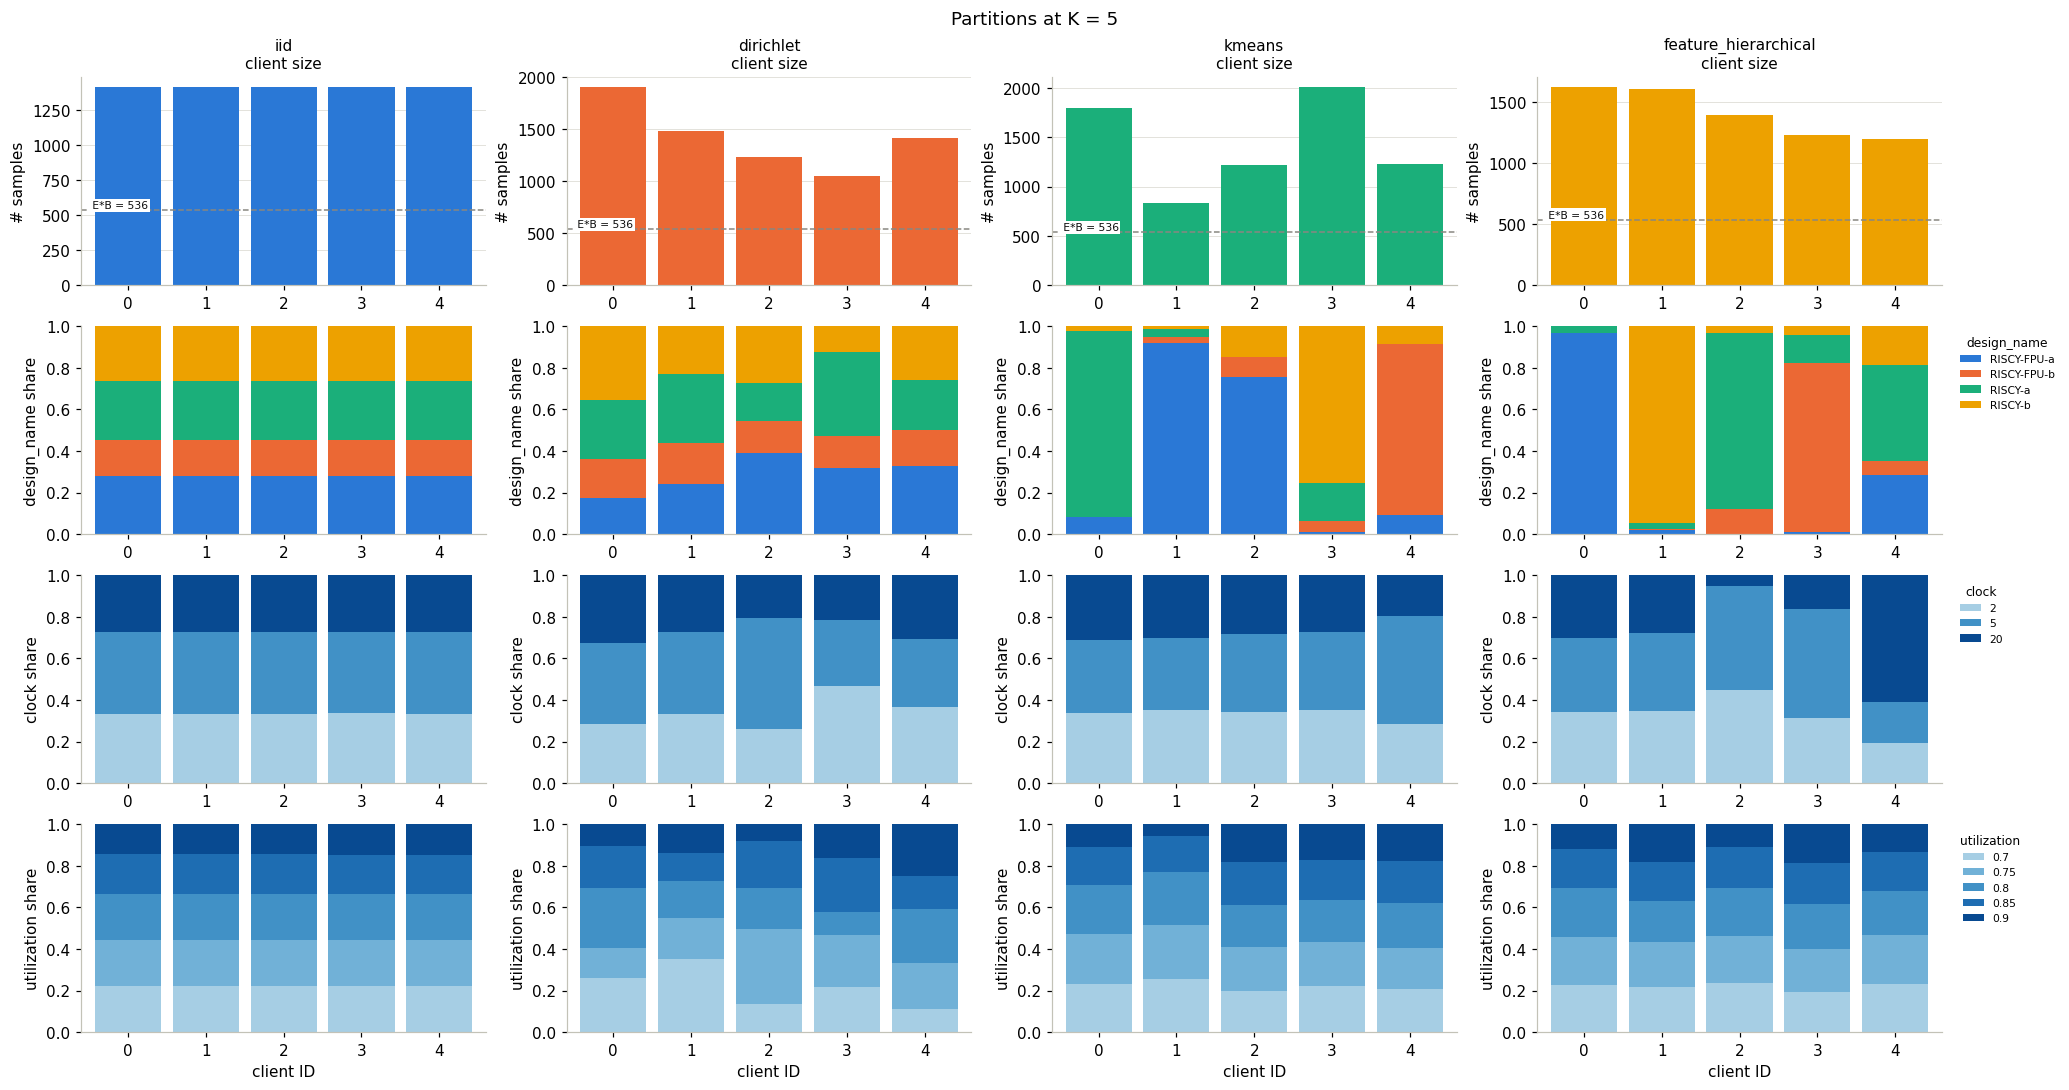

### K = 10 clients - m = 5 per round (50 % participation)

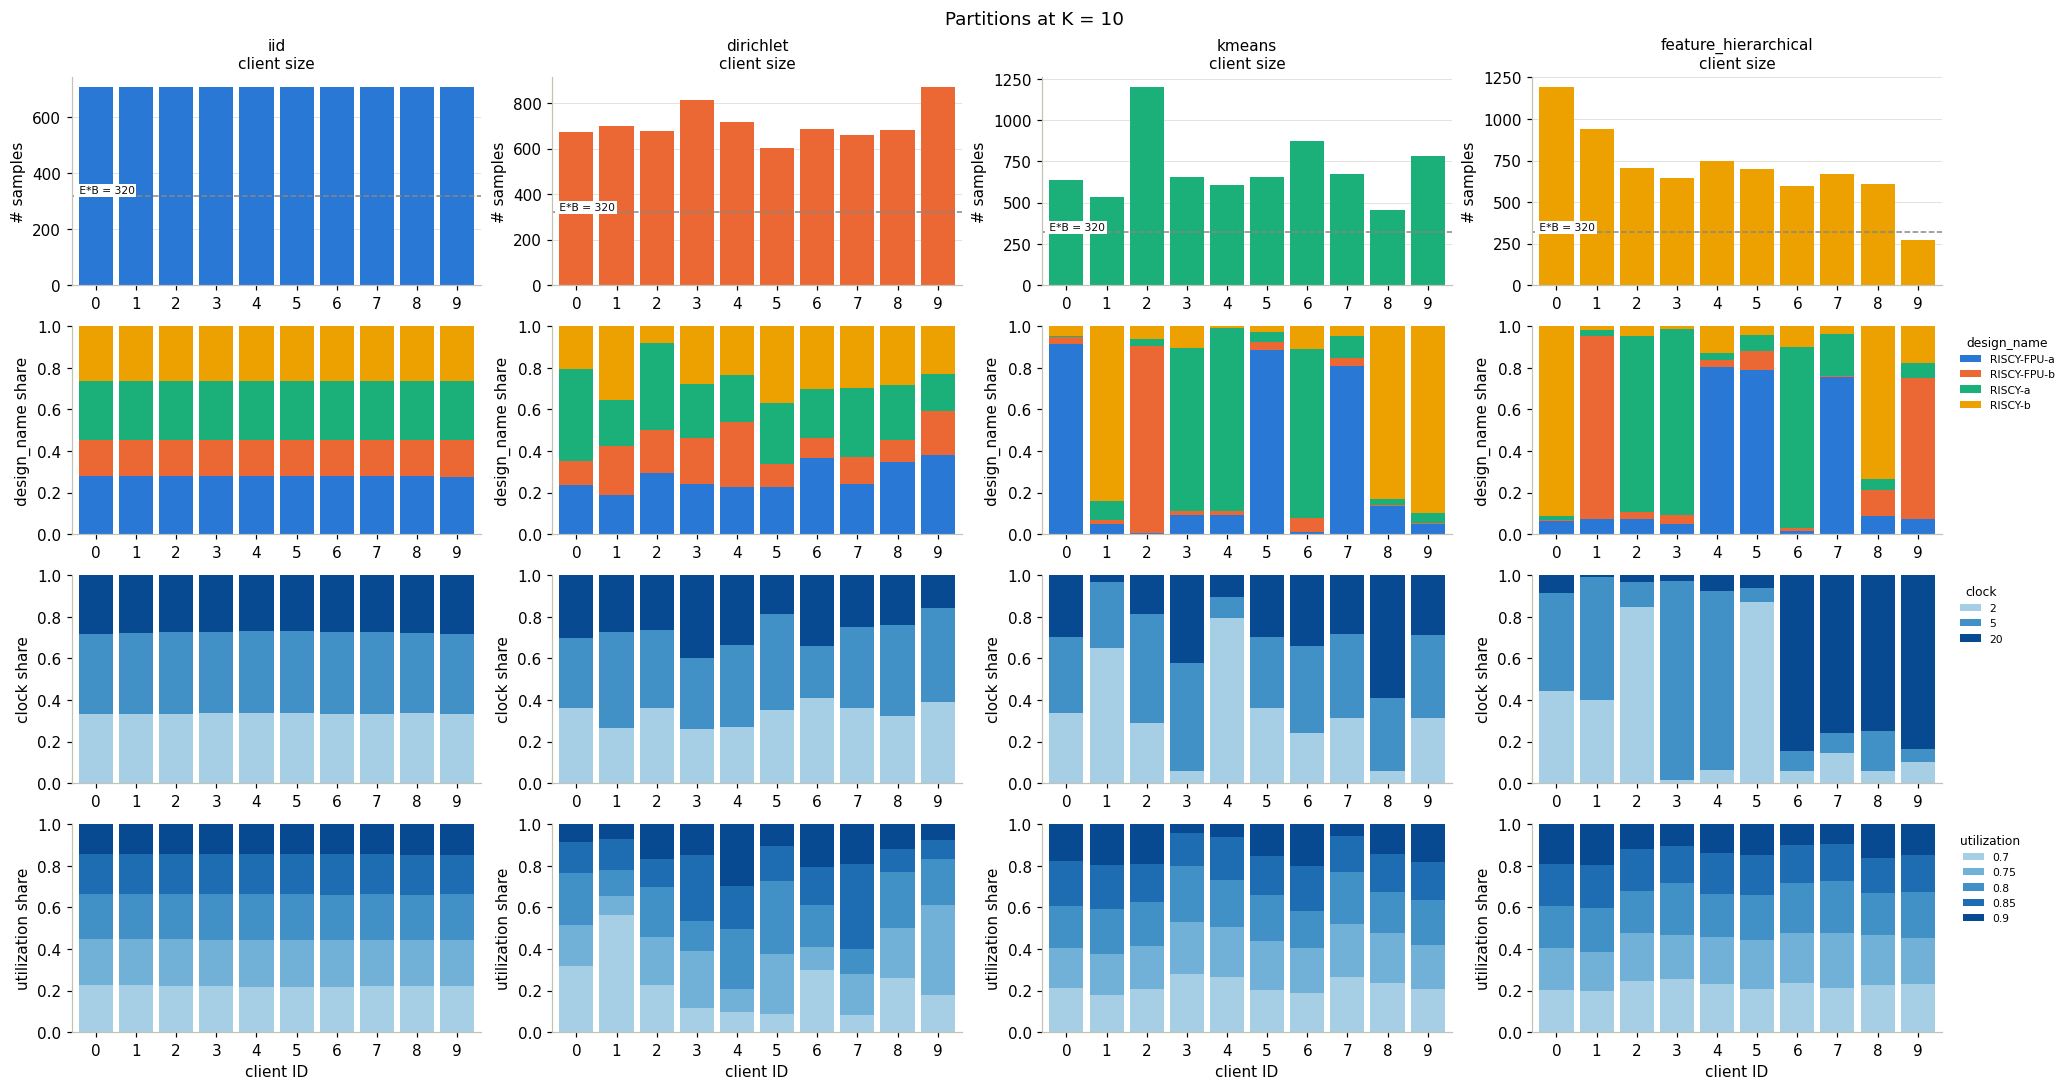

### K = 50 clients - m = 25 per round (50 % participation)

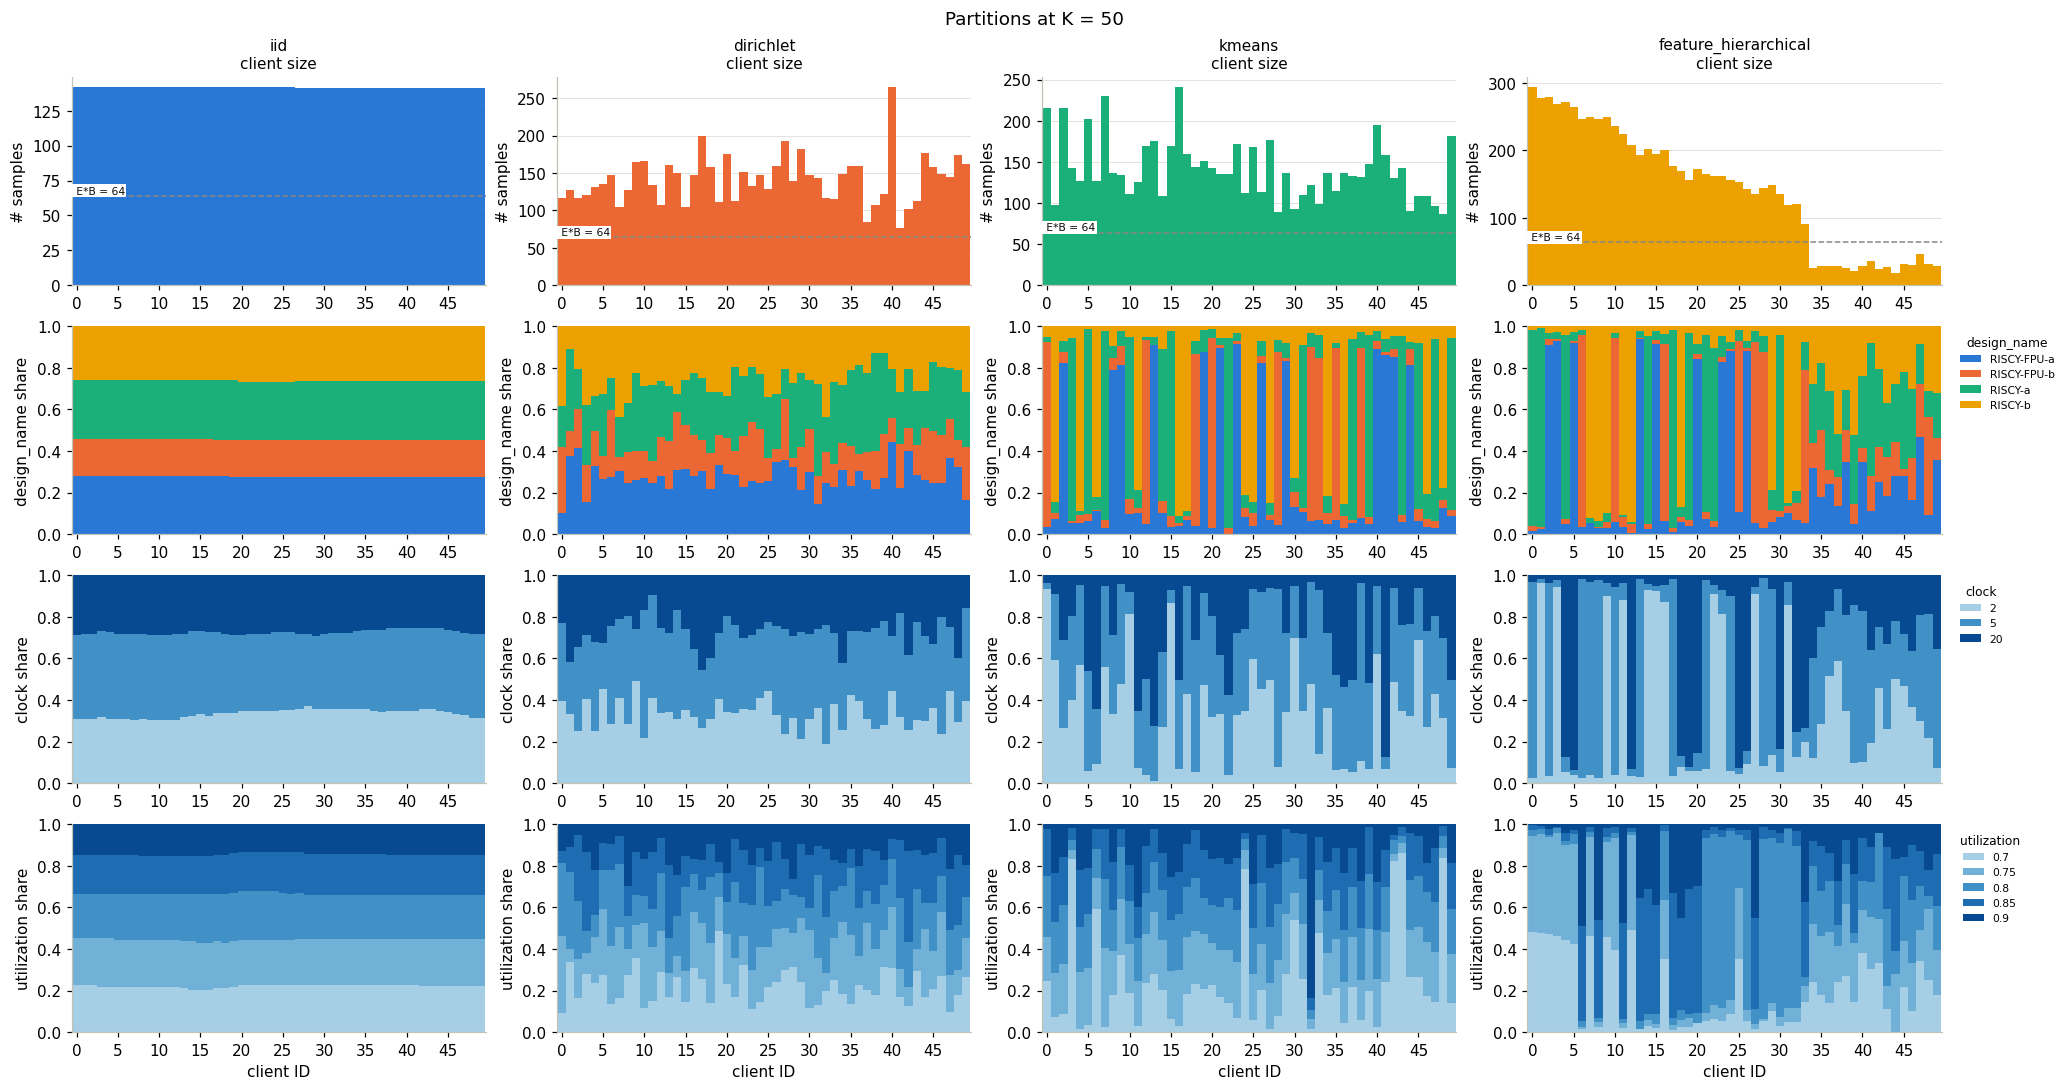

### K = 100 clients - m = 50 per round (50 % participation)

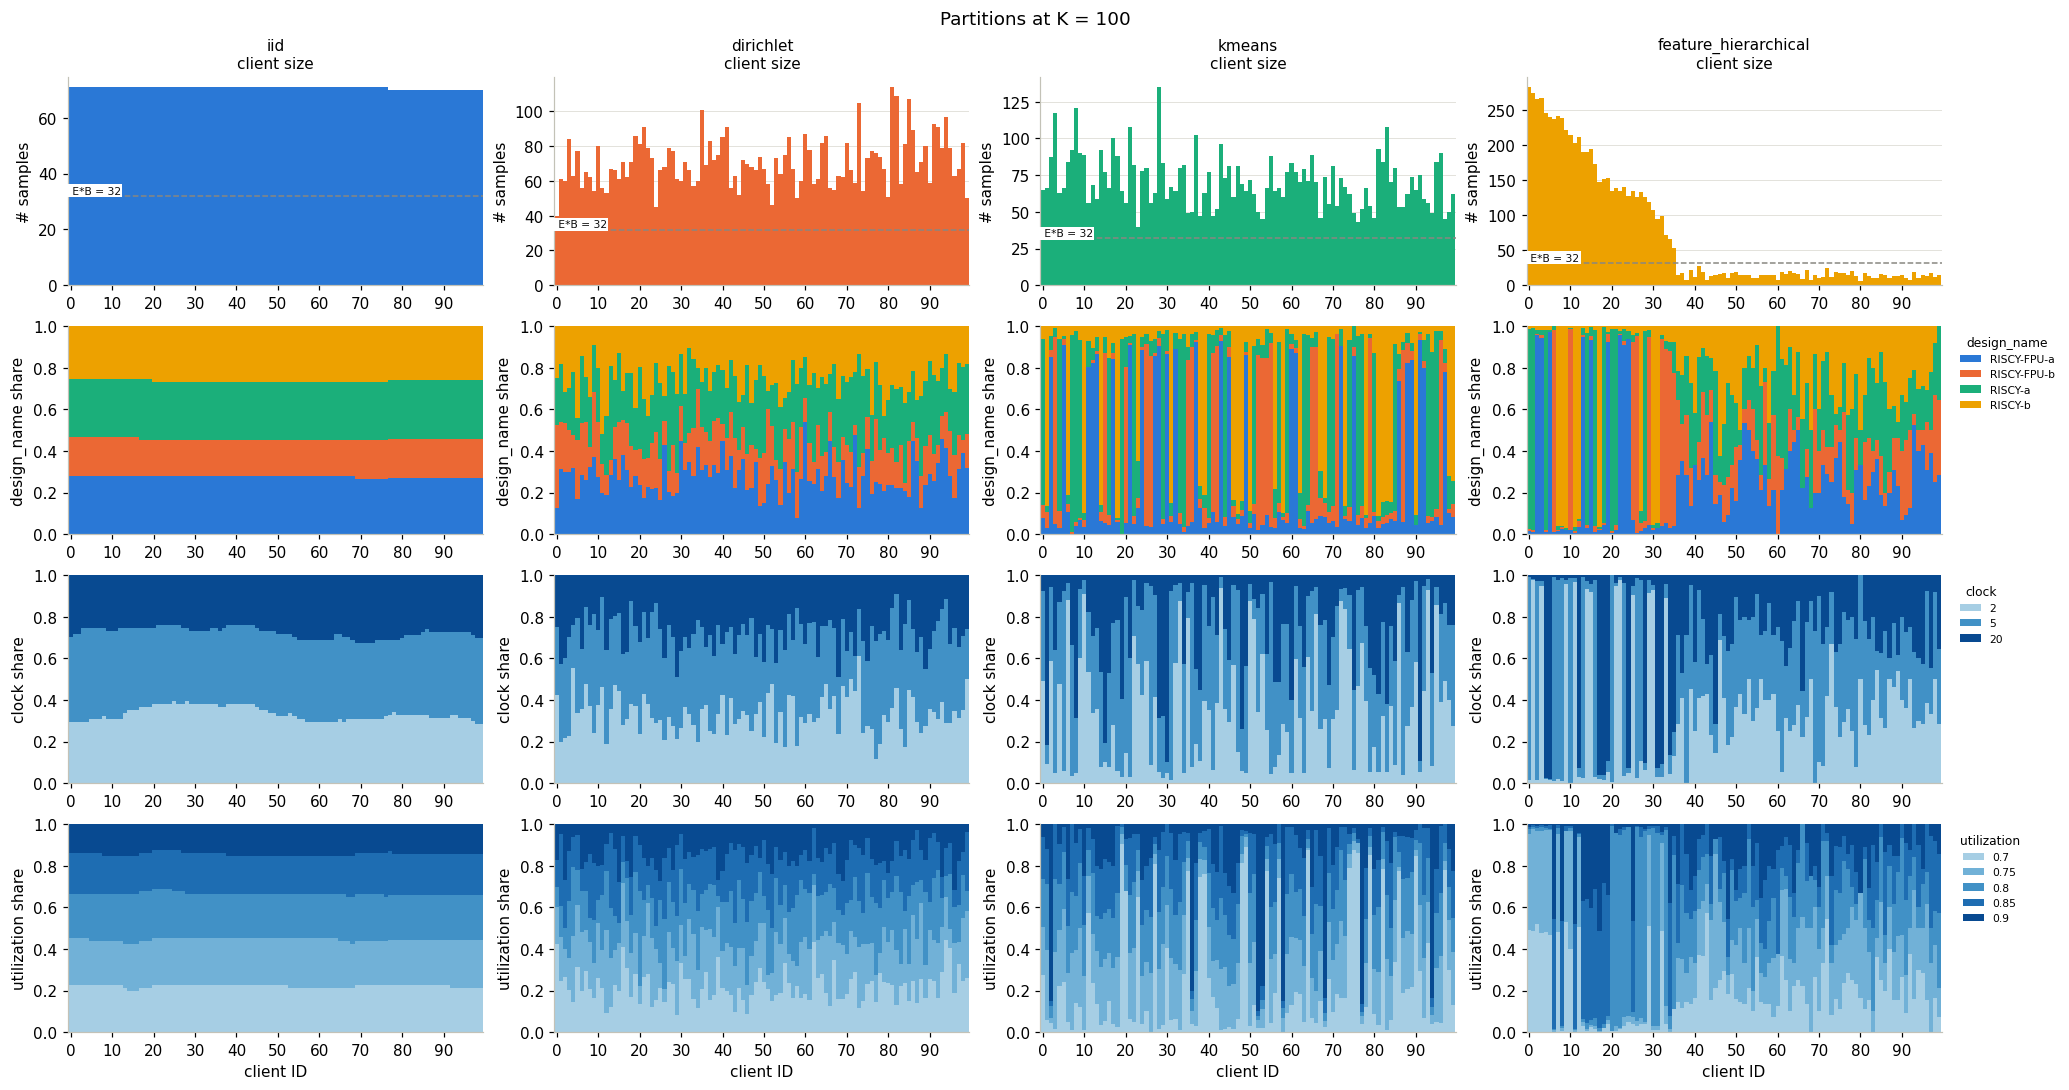

In [6]:
def step_cap_samples(run):
    strategy = (run.get('hparams') or {}).get('strategy') or {}
    E, B = strategy.get('local_epochs'), strategy.get('batch_size')
    return E * B if E and B else None


def bar_width(n_clients):
    # Gaps between bars help at small K but turn into stripes at large K.
    return 0.85 if n_clients <= 20 else 1.0


def plot_sizes(ax, sizes, cap, scheme):
    x = np.arange(len(sizes))
    ax.bar(x, sizes, width=bar_width(len(sizes)), color=SCHEME_COLOR[scheme])
    if cap:
        ax.axhline(cap, color=MUTED, linestyle='--', linewidth=1)
        ax.text(-0.5, cap, f' E*B = {cap}', ha='left', va='bottom', fontsize=7, color=INK,
                bbox={'facecolor': 'white', 'edgecolor': 'none', 'pad': 1})
    ax.set_title(f'{scheme}\nclient size')
    ax.set_ylabel('# samples')


def plot_composition(ax, counts, labels, col, legend):
    order = display_order(labels)
    counts = counts[:, order]
    labels = [labels[i] for i in order]
    share = counts / np.clip(counts.sum(axis=1, keepdims=True), 1, None)
    x = np.arange(len(share))
    bottom = np.zeros(len(share))
    for j, (label, color) in enumerate(zip(labels, value_colors(labels))):
        ax.bar(x, share[:, j], bottom=bottom, width=bar_width(len(share)), color=color, label=label)
        bottom += share[:, j]
    ax.set_ylim(0, 1)
    ax.set_ylabel(f'{col} share')
    ax.grid(False)
    if legend:
        ax.legend(fontsize=7, title=col, title_fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))


def client_ticks(ax, n):
    step = max(1, n // 10)
    ax.set_xticks(np.arange(0, n, step))
    ax.set_xlim(-0.6, n - 0.4)


for K in KS:
    size_header(K)
    rows = 1 + len(COMPOSITION_COLS)
    fig, axes = plt.subplots(rows, len(SCHEMES), figsize=(4.3 * len(SCHEMES) + 1.5, 2.3 * rows + 0.6),
                             constrained_layout=True, squeeze=False)
    for j, scheme in enumerate(SCHEMES):
        info = partitions.get((scheme, K))
        if info is None or info['sizes'] is None:
            for i in range(rows):
                mark_missing(axes[i, j], scheme if i == 0 else '', 'not run' if i == 0 else '')
            continue
        plot_sizes(axes[0, j], info['sizes'], step_cap_samples(train_runs[(scheme, K)]), scheme)
        for i, col in enumerate(COMPOSITION_COLS, start=1):
            if col in info['cols']:
                plot_composition(axes[i, j], info['cols'][col], info['labels'][col], col,
                                 legend=(j == len(SCHEMES) - 1))
            else:
                mark_missing(axes[i, j], '', f'{col} not tracked')
        for i in range(rows):
            client_ticks(axes[i, j], len(info['sizes']))
        axes[-1, j].set_xlabel('client ID')
    fig.suptitle(f'Partitions at K = {K}')
    plt.show()
    plt.close(fig)

In [7]:
def selection_counts(run):
    summary = run.get('summary') or {}
    if summary.get('selection_counts'):
        return np.asarray(summary['selection_counts'], dtype=float)
    for info in run.collect_sequence_info(sequence_types=['distributions']).get('distributions', []):
        if info['name'] == 'client_rounds':
            return np.asarray(info['values']['last'].to_np_histogram()[0], dtype=float)
    return np.array([])


comm_rows, selections = [], {}
for scheme, K, run in ordered(train_runs):
    summary = run.get('summary') or {}
    _, round_time = metric_series(run, 'Round Time (s)', {'subset': 'train'})
    _, round_comm = metric_series(run, 'Round Comm Cost (MB)', {'subset': 'train'})
    sel = selection_counts(run)
    selections[(scheme, K)] = sel
    rounds = len(round_time)
    comm_rows.append({
        'K': K,
        'scheme': scheme,
        'm': summary.get('round_clients', round_clients(K)),
        'rounds': rounds,
        'mean rounds / client': float(sel.mean()) if sel.size else np.nan,
        'min rounds / client': int(sel.min()) if sel.size else None,
        'max rounds / client': int(sel.max()) if sel.size else None,
        'never selected': int((sel == 0).sum()) if sel.size else None,
        'total comm (MB)': summary.get('total_comm_mb', float(round_comm.sum()) if round_comm.size else np.nan),
        'comm / round (MB)': float(round_comm.mean()) if round_comm.size else np.nan,
        'mean round time (s)': float(round_time.mean()) if round_time.size else np.nan,
        'train wall time (min)': float(round_time.sum() / 60) if round_time.size else np.nan,
    })

comm_df = pd.DataFrame(comm_rows)
if not comm_df.empty:
    comm_df = comm_df.set_index(['K', 'scheme'])
    display(comm_df.round(3))

# Selection only depends on runtime.seed and K, so it should match across schemes.
for K in KS:
    sels = [selections[(s, K)] for s in SCHEMES if (s, K) in selections and selections[(s, K)].size]
    same = all(np.array_equal(sels[0], s) for s in sels[1:]) if sels else None
    print(f'K = {K}: client selection identical across the {len(sels)} logged scheme(s): {same}')

m  rounds  mean rounds / client  \
K   scheme                                                   
5   iid                    3     200                 120.0   
    dirichlet              3     200                 120.0   
    kmeans                 3     200                 120.0   
    feature_hierarchical   3     200                 120.0   
10  iid                    5     200                 100.0   
    dirichlet              5     200                 100.0   
    kmeans                 5     200                 100.0   
    feature_hierarchical   5     200                 100.0   
50  iid                   25     200                 100.0   
    dirichlet             25     200                 100.0   
    kmeans                25     200                 100.0   
    feature_hierarchical  25     200                 100.0   
100 iid                   50     200                 100.0   
    dirichlet             50     200                 100.0   
    kmeans                50     200                 100.0   
    feature_hierarchical  50     200                 100.0   

                          min rounds / client  max rounds / client  \
K   scheme                                                           
5   iid                                   103                  127   
    dirichlet                             103                  127   
    kmeans                                103                  127   
    feature_hierarchical                  103                  127   
10  iid                                    88                  114   
    dirichlet                              88                  114   
    kmeans                                 88                  114   
    feature_hierarchical                   88                  114   
50  iid                                    85                  121   
    dirichlet                              85                  121   
    kmeans                                 85                  121   
    feature_hierarchical                   85                  121   
100 iid                                    81                  121   
    dirichlet                              81                  121   
    kmeans                                 81                  121   
    feature_hierarchical                   81                  121   

                          never selected  total comm (MB)  comm / round (MB)  \
K   scheme                                                                     
5   iid                                0          553.422              2.767   
    dirichlet                          0          553.422              2.767   
    kmeans                             0          553.422              2.767   
    feature_hierarchical               0          553.422              2.767   
10  iid                                0          922.371              4.612   
    dirichlet                          0          922.371              4.612   
    kmeans                             0          922.371              4.612   
    feature_hierarchical               0          922.371              4.612   
50  iid                                0         4611.855             23.059   
    dirichlet                          0         4611.855             23.059   
    kmeans                             0         4611.855             23.059   
    feature_hierarchical               0         4611.855             23.059   
100 iid                                0         9223.709             46.119   
    dirichlet                          0         9223.709             46.119   
    kmeans                             0         9223.709             46.119   
    feature_hierarchical               0         9223.709             46.119   

                          mean round time (s)  train wall time (min)  
K   scheme                                                            
5   iid                                 9.773                 32.5

K = 5: client selection identical across the 4 logged scheme(s): True
K = 10: client selection identical across the 4 logged scheme(s): True
K = 50: client selection identical across the 4 logged scheme(s): True
K = 100: client selection identical across the 4 logged scheme(s): True


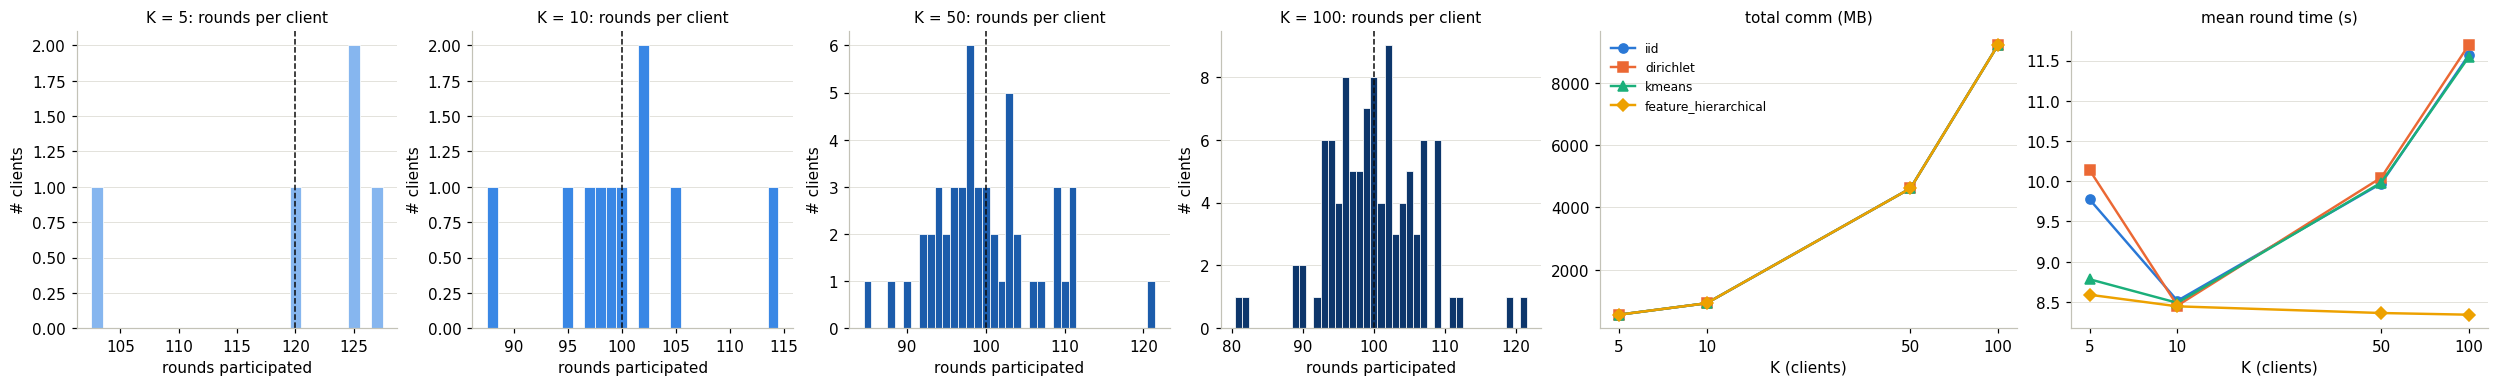

In [8]:
if not comm_df.empty:
    fig, axes = plt.subplots(1, len(KS) + 2, figsize=(3.4 * len(KS) + 9, 3.4), constrained_layout=True,
                             gridspec_kw={'width_ratios': [1] * len(KS) + [1.3, 1.3]})
    # Rounds participated per client, one panel per K (first logged scheme;
    # the check above says whether the others match).
    for ax, K in zip(axes, KS):
        sel = next((selections[(s, K)] for s in SCHEMES if (s, K) in selections), np.array([]))
        if not sel.size:
            mark_missing(ax, f'K = {K}')
            continue
        ax.hist(sel, bins=np.arange(sel.min(), sel.max() + 2) - 0.5, color=K_COLOR[K], edgecolor='white', linewidth=0.5)
        ax.axvline(sel.mean(), color=INK, linestyle='--', linewidth=1)
        ax.set_title(f'K = {K}: rounds per client')
        ax.set_xlabel('rounds participated')
        ax.set_ylabel('# clients')
    for ax, col in zip(axes[len(KS):], ['total comm (MB)', 'mean round time (s)']):
        for scheme in SCHEMES:
            if scheme not in comm_df.index.get_level_values('scheme'):
                continue
            sub = comm_df.xs(scheme, level='scheme')
            ax.plot(sub.index, sub[col], color=SCHEME_COLOR[scheme], marker=SCHEME_MARKER[scheme], label=scheme)
        ax.set_title(col)
        log_k_axis(ax)
    scheme_legend(axes[-2])
    plt.show()
    plt.close(fig)

## Training curves

For every K: the mean client train loss per round of the four schemes overlaid (thin = raw, bold = centred rolling mean over `SMOOTH` rounds), then one panel per scheme with every client's own loss trace (a client only has points in the rounds it was sampled) and the per-round mean in black. The table and the cross-size panels compare the smoothed curves across K.

### K = 5 clients - m = 3 per round (60 % participation)

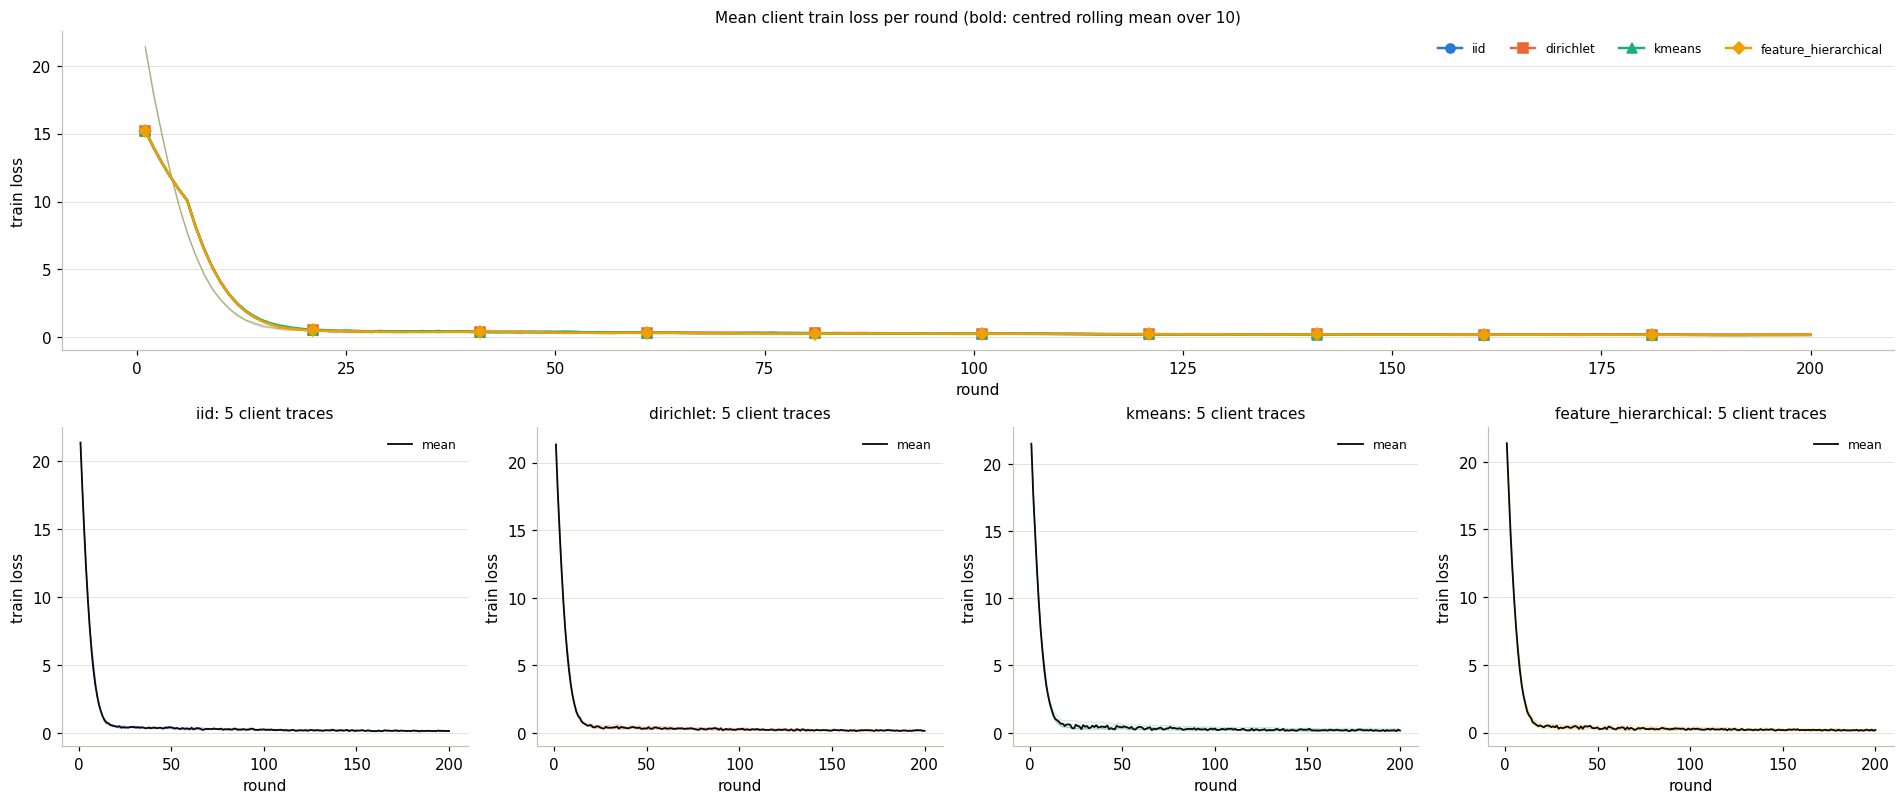

### K = 10 clients - m = 5 per round (50 % participation)

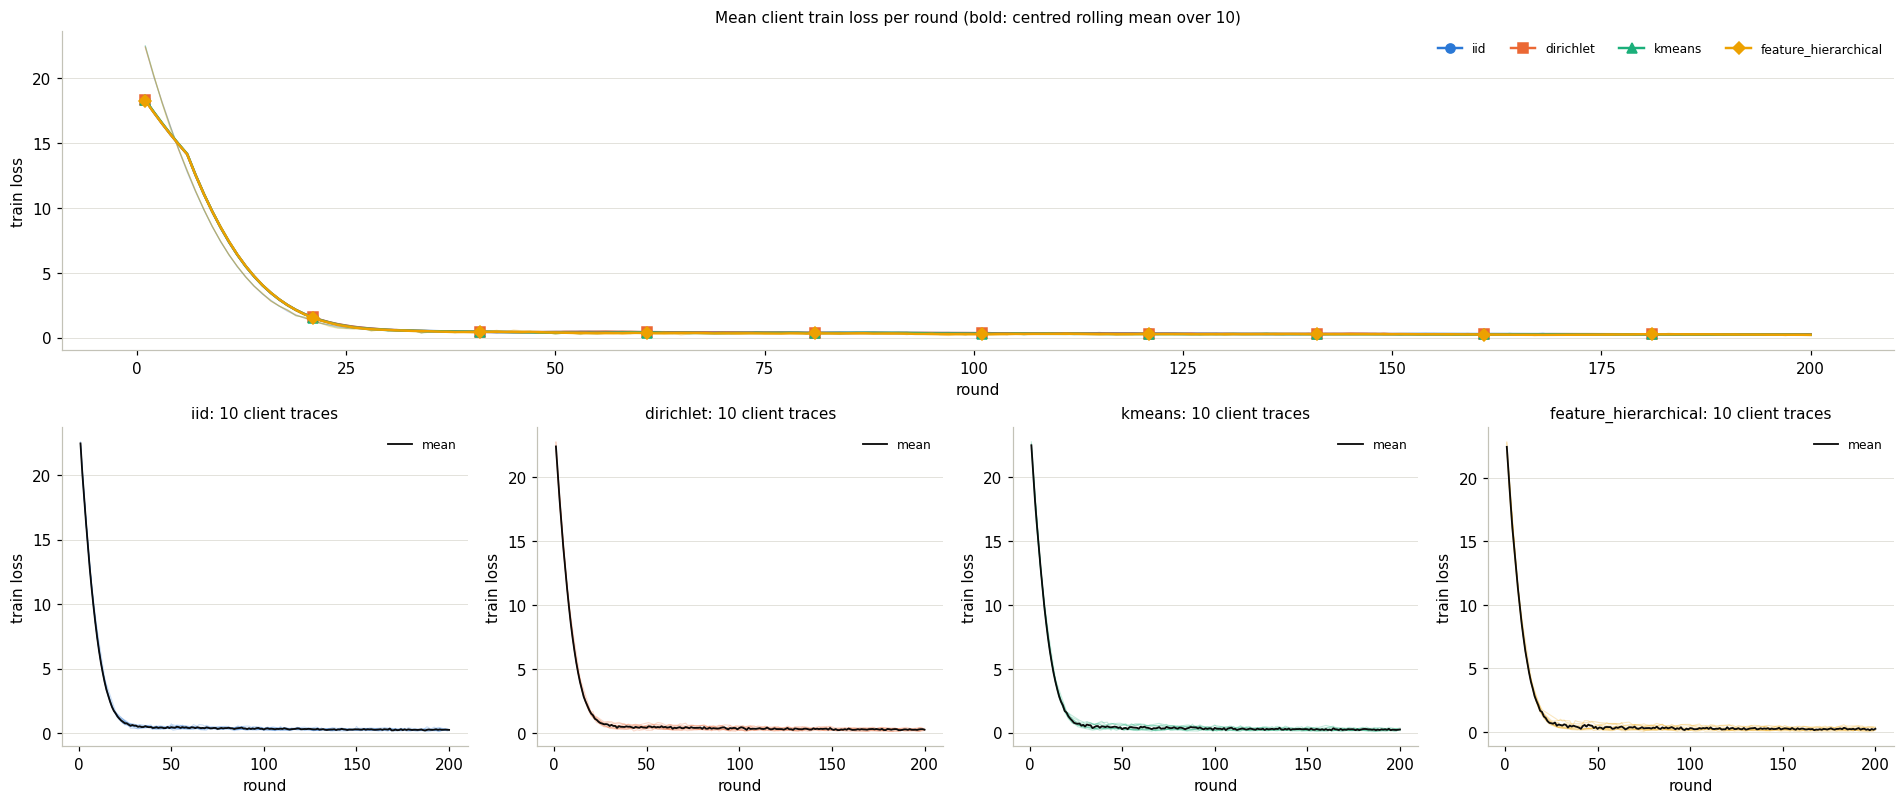

### K = 50 clients - m = 25 per round (50 % participation)

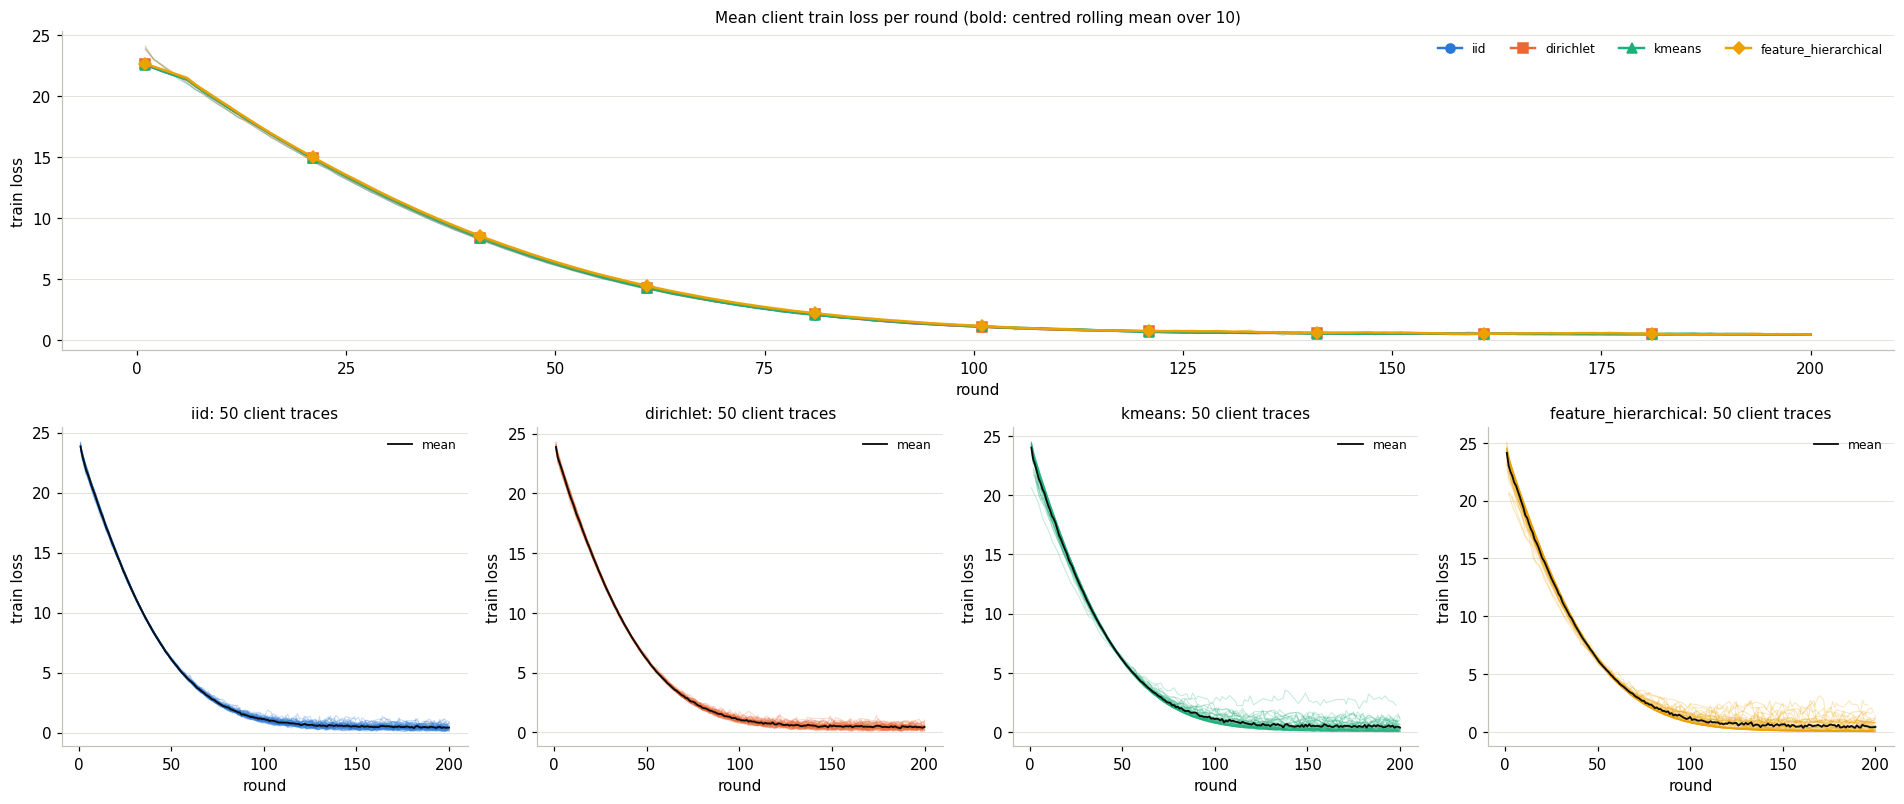

### K = 100 clients - m = 50 per round (50 % participation)

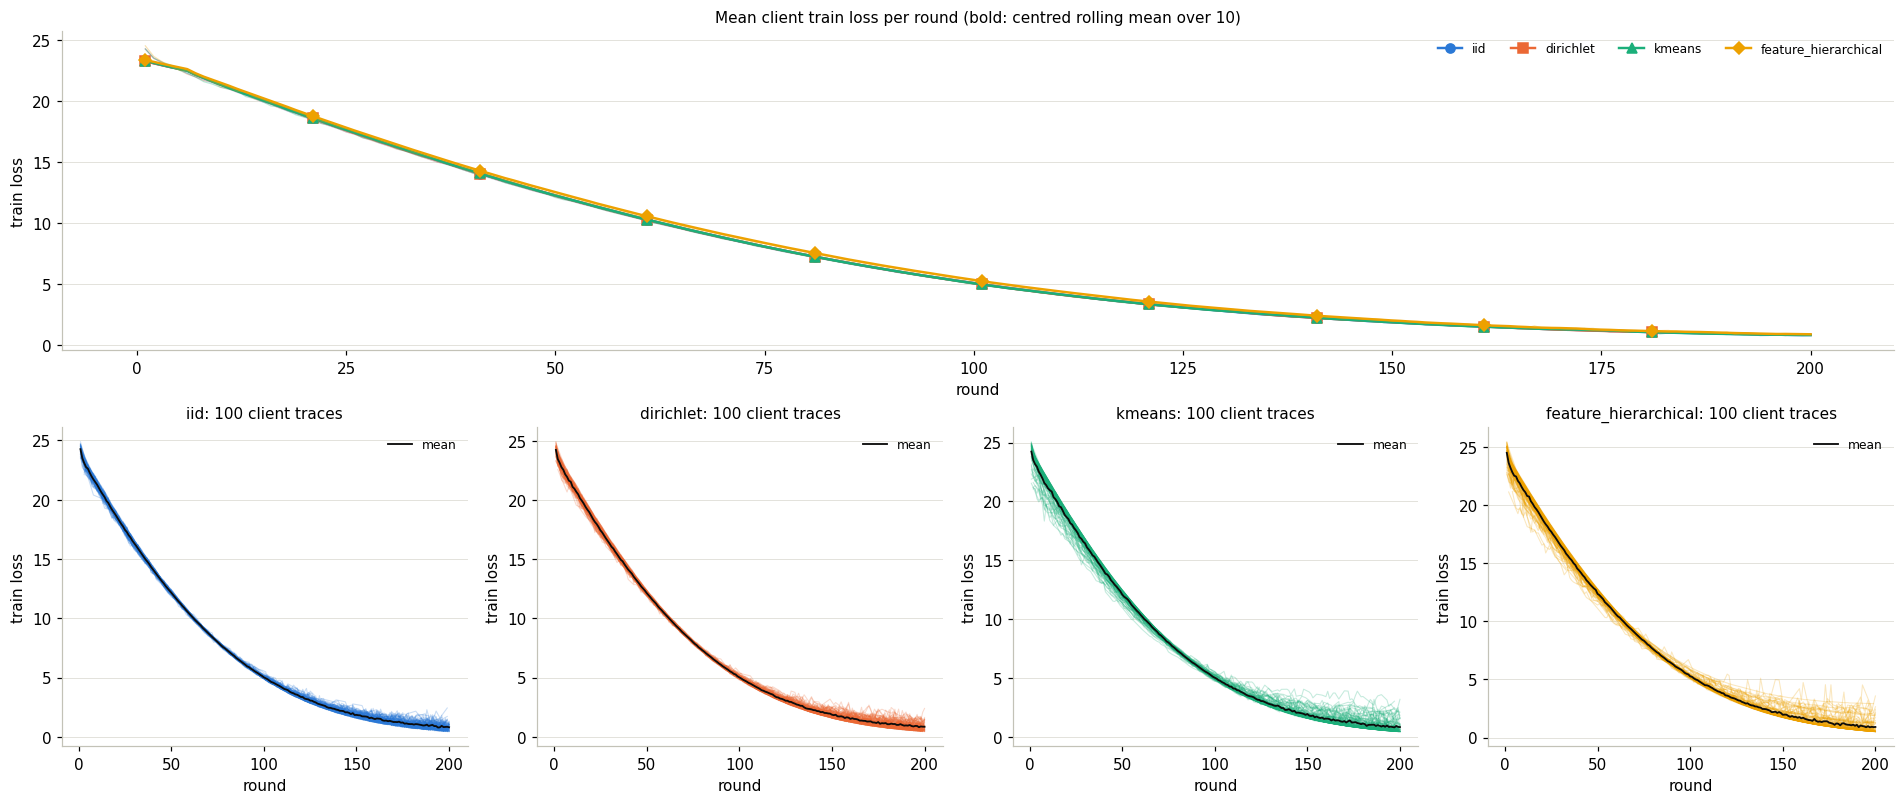

rounds  final mean loss  mean loss, last 10 rounds  \
K   scheme                                                                     
5   iid                      200          0.17988                    0.17923   
    dirichlet                200          0.16657                    0.18497   
    kmeans                   200          0.16758                    0.17275   
    feature_hierarchical     200          0.19149                    0.17416   
10  iid                      200          0.24445                    0.26003   
    dirichlet                200          0.23509                    0.24597   
    kmeans                   200          0.24052                    0.22668   
    feature_hierarchical     200          0.25843                    0.22394   
50  iid                      200          0.42027                    0.43120   
    dirichlet                200          0.45807                    0.44396   
    kmeans                   200          0.36275                    0.44525   
    feature_hierarchical     200          0.43434                    0.45614   
100 iid                      200          0.81577                    0.87229   
    dirichlet                200          0.84532                    0.89006   
    kmeans                   200          0.82500                    0.86804   
    feature_hierarchical     200          0.90691                    0.93232   

                          min mean loss  clients with a loss  
K   scheme                                                    
5   iid                         0.14933                    5  
    dirichlet                   0.14611                    5  
    kmeans                      0.11974                    5  
    feature_hierarchical        0.13260                    5  
10  iid                         0.19623                   10  
    dirichlet                   0.19985                   10  
    kmeans                      0.17949                   10  
    feature_hierarchical        0.14456                   10  
50  iid                         0.37336                   50  
    dirichlet                   0.34405                   50  
    kmeans                      0.35830                   50  
    feature_hierarchical        0.34292                   50  
100 iid                         0.79229                  100  
    dirichlet                   0.80508                  100  
    kmeans                      0.80036                  100  
    feature_hierarchical        0.87842                  100

In [9]:
SMOOTH = 10


def smooth(vals):
    # Centred, so the smoothed curve does not lag the raw one.
    return pd.Series(vals).rolling(SMOOTH, min_periods=1, center=True).mean().to_numpy()


def client_losses(run):
    # {client_id: (steps, values)} for `Client Train Loss`.
    out = {}
    for info in run.collect_sequence_info(sequence_types=['metric']).get('metric', []):
        ctx = info.get('context') or {}
        if info.get('name') != 'Client Train Loss' or ctx.get('client_id') is None:
            continue
        steps, vals = metric_series(run, 'Client Train Loss', ctx)
        if steps.size:
            out[int(ctx['client_id'])] = (steps, vals)
    return out


mean_losses = {key: metric_series(run, 'Mean Client Train Loss', {'subset': 'train'})
               for key, run in train_runs.items()}

loss_rows = []
for K in KS:
    size_header(K)
    fig, axd = plt.subplot_mosaic([['mean'] * len(SCHEMES), SCHEMES], figsize=(4.3 * len(SCHEMES), 7.2),
                                  constrained_layout=True)
    for scheme in SCHEMES:
        ax = axd[scheme]
        if (scheme, K) not in train_runs:
            mark_missing(ax, scheme)
            continue
        steps, vals = mean_losses[(scheme, K)]
        if vals.size:
            axd['mean'].plot(steps, vals, color=SCHEME_COLOR[scheme], alpha=0.3, linewidth=0.8)
            axd['mean'].plot(steps, smooth(vals), color=SCHEME_COLOR[scheme], marker=SCHEME_MARKER[scheme],
                             markevery=max(1, len(steps) // 10), label=scheme)
        per_client = client_losses(train_runs[(scheme, K)])
        for c_steps, c_vals in per_client.values():
            ax.plot(c_steps, c_vals, color=SCHEME_COLOR[scheme], alpha=0.25, linewidth=0.7)
        if vals.size:
            ax.plot(steps, vals, color=INK, linewidth=1.2, label='mean')
            ax.legend(fontsize=8)
        ax.set_title(f'{scheme}: {len(per_client)} client traces')
        ax.set_xlabel('round')
        ax.set_ylabel('train loss')
        loss_rows.append({
            'K': K,
            'scheme': scheme,
            'rounds': len(vals),
            'final mean loss': float(vals[-1]) if vals.size else np.nan,
            f'mean loss, last {SMOOTH} rounds': float(vals[-SMOOTH:].mean()) if vals.size else np.nan,
            'min mean loss': float(vals.min()) if vals.size else np.nan,
            'clients with a loss': len(per_client),
        })
    axd['mean'].set_title(f'Mean client train loss per round (bold: centred rolling mean over {SMOOTH})')
    axd['mean'].set_xlabel('round')
    axd['mean'].set_ylabel('train loss')
    if axd['mean'].lines:
        axd['mean'].legend(fontsize=8, ncol=len(SCHEMES))
    plt.show()
    plt.close(fig)

loss_df = pd.DataFrame(loss_rows)
if not loss_df.empty:
    loss_df = loss_df.set_index(['K', 'scheme'])
    display(loss_df.round(5))

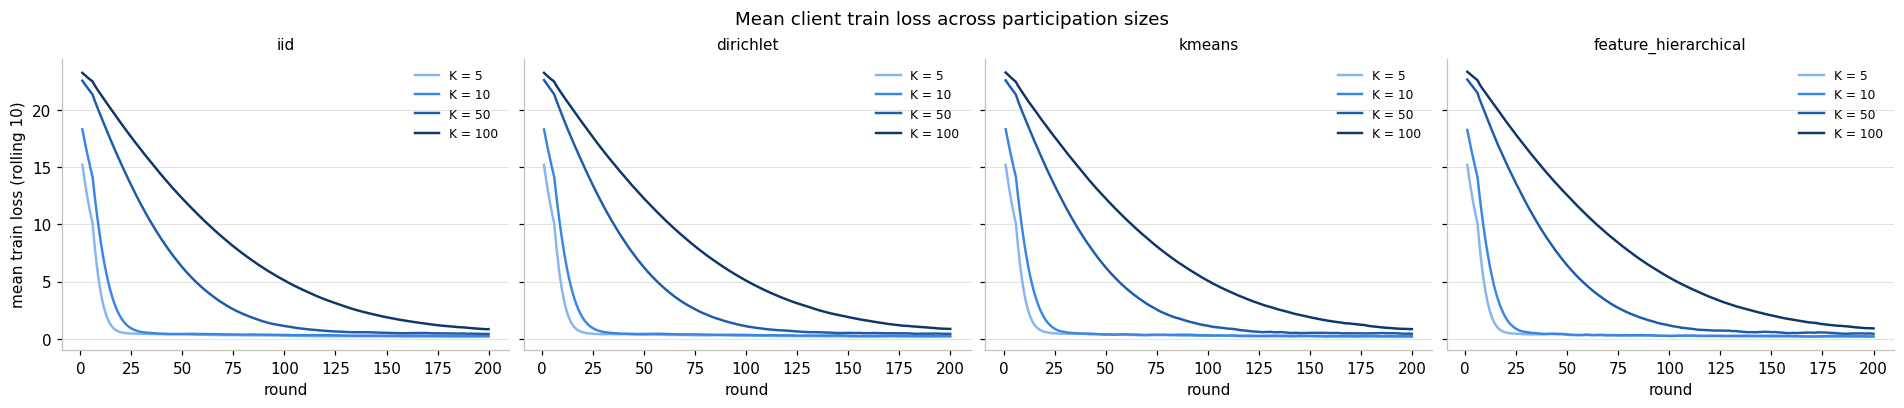

In [10]:
# Cross-size comparison: smoothed mean train loss, one panel per scheme, one line per K.
if train_runs:
    fig, axes = plt.subplots(1, len(SCHEMES), figsize=(4.3 * len(SCHEMES), 3.6), constrained_layout=True, sharey=True)
    for ax, scheme in zip(axes, SCHEMES):
        plotted = False
        for K in KS:
            steps, vals = mean_losses.get((scheme, K), (np.array([]), np.array([])))
            if vals.size:
                ax.plot(steps, smooth(vals), color=K_COLOR[K], label=f'K = {K}')
                plotted = True
        if not plotted:
            mark_missing(ax, scheme)
            continue
        ax.set_title(scheme)
        ax.set_xlabel('round')
        ax.legend(fontsize=8)
    axes[0].set_ylabel(f'mean train loss (rolling {SMOOTH})')
    fig.suptitle('Mean client train loss across participation sizes')
    plt.show()
    plt.close(fig)

## Test configurations

In [11]:
test_conf_rows = []
for scheme, K, run in ordered(test_runs):
    hparams = run.get('hparams') or {}
    evaluation = hparams.get('evaluation') or {}
    test_conf_rows.append({
        'K': K,
        'scheme': scheme,
        'checkpoint': hparams.get('checkpoint'),
        'model': (hparams.get('model') or {}).get('type'),
        'eval_metric': evaluation.get('eval_metric'),
        'threshold': evaluation.get('threshold'),
        'plot_roc': evaluation.get('plot_roc'),
        'save_path': evaluation.get('save_path'),
        'run': run.hash,
    })

if test_conf_rows:
    display(pd.DataFrame(test_conf_rows).set_index(['K', 'scheme']))

checkpoint  \
K   scheme                                                                    
5   iid                   ./work_dirs/sweep_clients/fedavg_iid_groupnorm...   
    dirichlet             ./work_dirs/sweep_clients/fedavg_dirichlet_gro...   
    kmeans                ./work_dirs/sweep_clients/fedavg_kmeans_groupn...   
    feature_hierarchical  ./work_dirs/sweep_clients/fedavg_feature_hiera...   
10  iid                   ./work_dirs/sweep_clients/fedavg_iid_groupnorm...   
    dirichlet             ./work_dirs/sweep_clients/fedavg_dirichlet_gro...   
    kmeans                ./work_dirs/sweep_clients/fedavg_kmeans_groupn...   
    feature_hierarchical  ./work_dirs/sweep_clients/fedavg_feature_hiera...   
50  iid                   ./work_dirs/sweep_clients/fedavg_iid_groupnorm...   
    dirichlet             ./work_dirs/sweep_clients/fedavg_dirichlet_gro...   
    kmeans                ./work_dirs/sweep_clients/fedavg_kmeans_groupn...   
    feature_hierarchical  ./work_dirs/sweep_clients/fedavg_feature_hiera...   
100 iid                   ./work_dirs/sweep_clients/fedavg_iid_groupnorm...   
    dirichlet             ./work_dirs/sweep_clients/fedavg_dirichlet_gro...   
    kmeans                ./work_dirs/sweep_clients/fedavg_kmeans_groupn...   
    feature_hierarchical  ./work_dirs/sweep_clients/fedavg_feature_hiera...   

                                      model   eval_metric  threshold  \
K   scheme                                                             
5   iid                   RouteNetGroupNorm  [NRMS, SSIM]        0.1   
    dirichlet             RouteNetGroupNorm  [NRMS, SSIM]        0.1   
    kmeans                RouteNetGroupNorm  [NRMS, SSIM]        0.1   
    feature_hierarchical  RouteNetGroupNorm  [NRMS, SSIM]        0.1   
10  iid                   RouteNetGroupNorm  [NRMS, SSIM]        0.1   
    dirichlet             RouteNetGroupNorm  [NRMS, SSIM]        0.1   
    kmeans                RouteNetGroupNorm  [NRMS, SSIM]        0.1   
    feature_hierarchical  RouteNetGroupNorm  [NRMS, SSIM]        0.1   
50  iid                   RouteNetGroupNorm  [NRMS, SSIM]        0.1   
    dirichlet             RouteNetGroupNorm  [NRMS, SSIM]        0.1   
    kmeans                RouteNetGroupNorm  [NRMS, SSIM]        0.1   
    feature_hierarchical  RouteNetGroupNorm  [NRMS, SSIM]        0.1   
100 iid                   RouteNetGroupNorm  [NRMS, SSIM]        0.1   
    dirichlet             RouteNetGroupNorm  [NRMS, SSIM]        0.1   
    kmeans                RouteNetGroupNorm  [NRMS, SSIM]        0.1   
    feature_hierarchical  RouteNetGroupNorm  [NRMS, SSIM]        0.1   

                          plot_roc  \
K   scheme                           
5   iid                       True   
    dirichlet                 True   
    kmeans                    True   
    feature_hierarchical      True   
10  iid                       True   
    dirichlet                 True   
    kmeans                    True   
    feature_hierarchical      True   
50  iid                       True   
    dirichlet                 True   
    kmeans                    True   
    feature_hierarchical      True   
100 iid                       True   
    dirichlet                 True   
    kmeans                    True   
    feature_hierarchical      True   

                                                                  save_path  \
K   scheme                                                                    
5   iid                   ./work_dirs/sweep_clients/fedavg_iid_groupnorm_c5   
    dirichlet             ./work_dirs/sweep_clients/fedavg_dirichlet_gro...   
    kmeans                ./work_dirs/sweep_clients/fedavg_kmeans_groupn...   
    feature_hierarchical  ./work_dirs/sweep_clients/fedavg_feature_hiera...   
10  iid                   ./work_dirs/sweep_clients/fedavg_iid_groupnorm...   
    dirichlet             ./work_dirs/sweep_clients/fedavg_dirichlet_gro...   
    kmeans                ./

## Test metric distributions

### K = 5 clients - m = 3 per round (60 % participation)

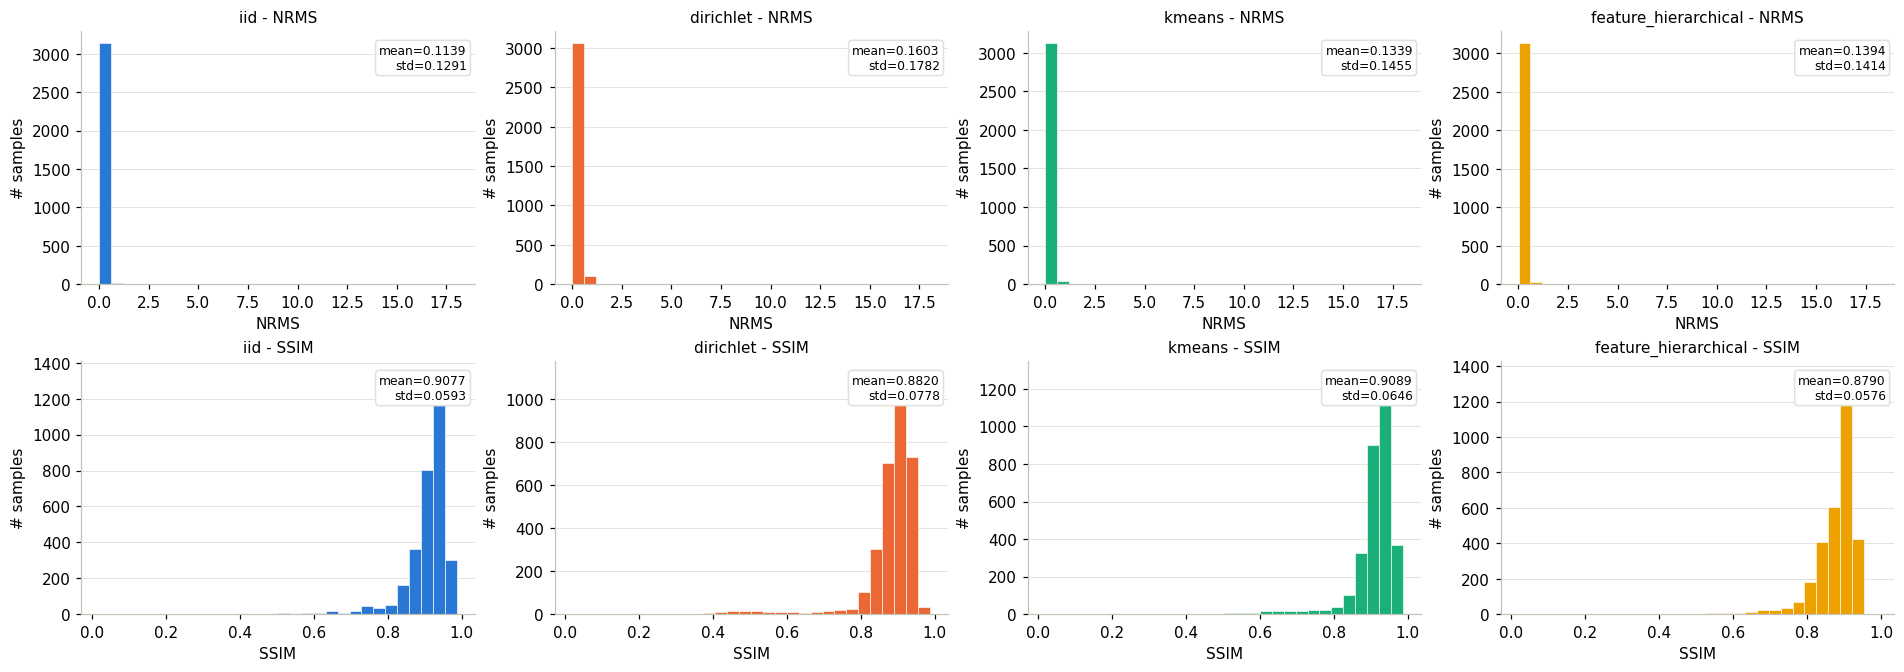

### K = 10 clients - m = 5 per round (50 % participation)

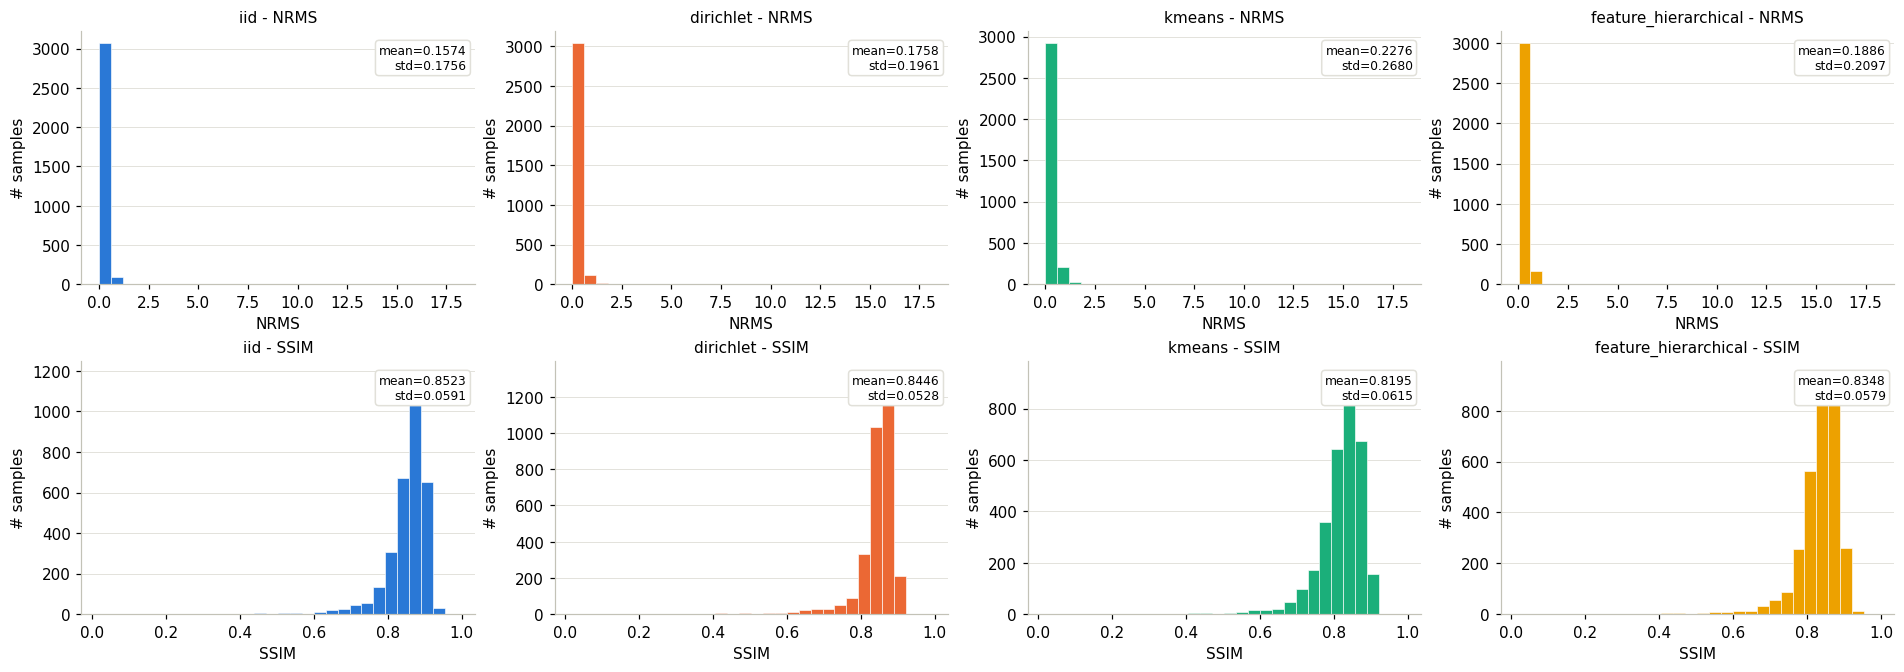

### K = 50 clients - m = 25 per round (50 % participation)

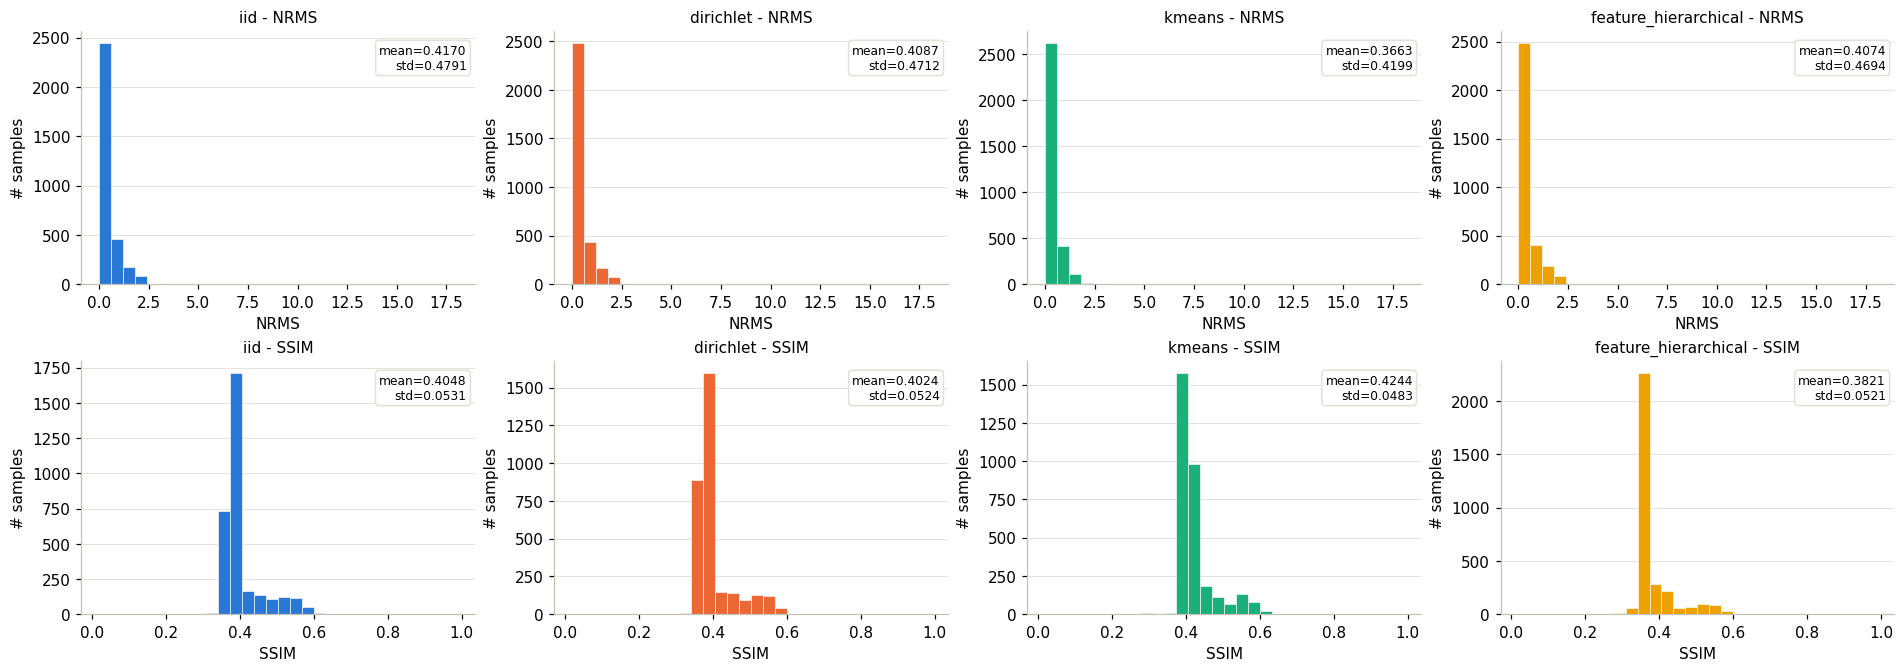

### K = 100 clients - m = 50 per round (50 % participation)

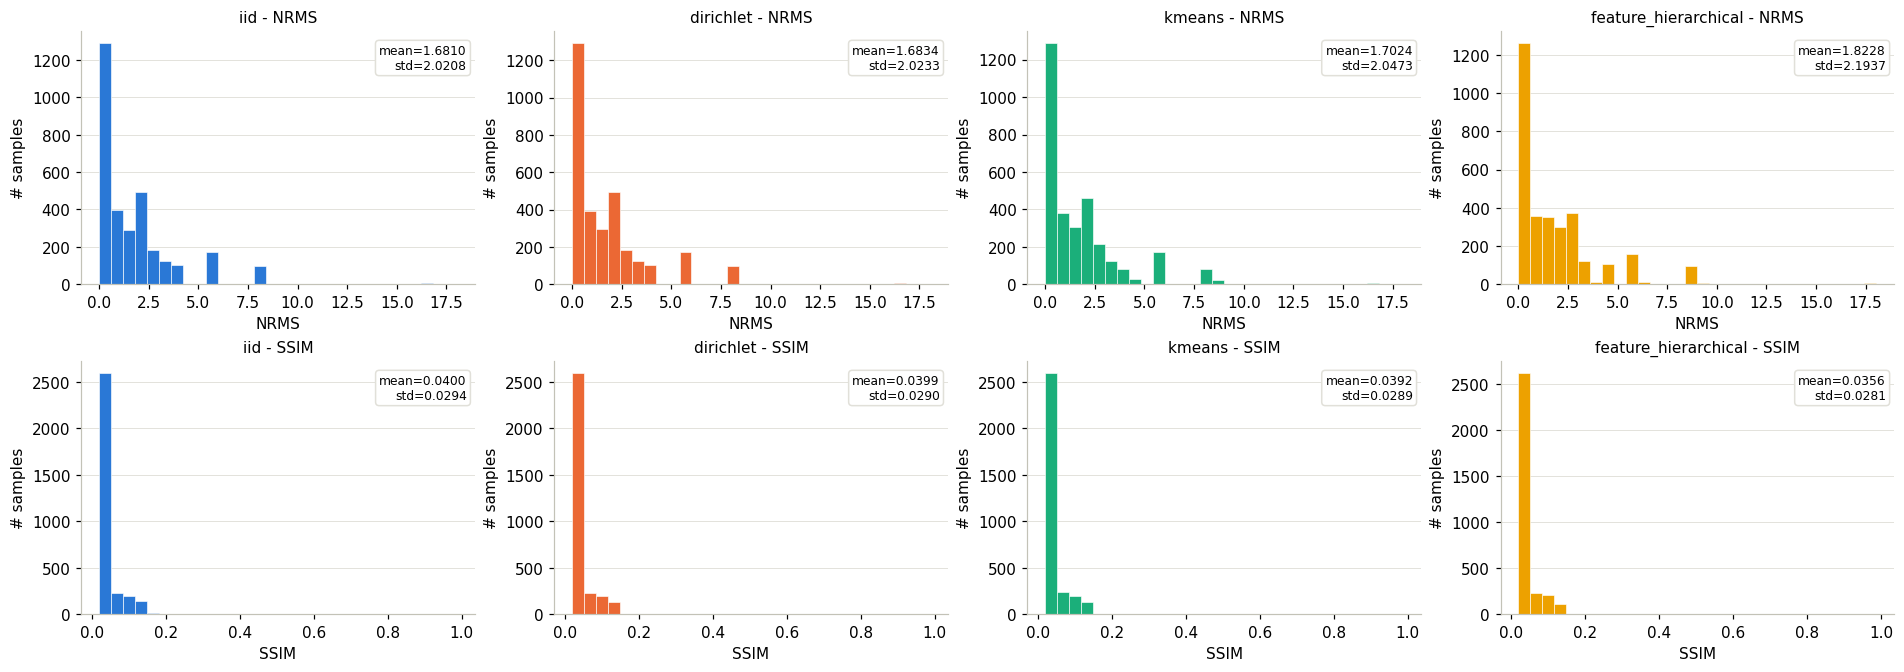

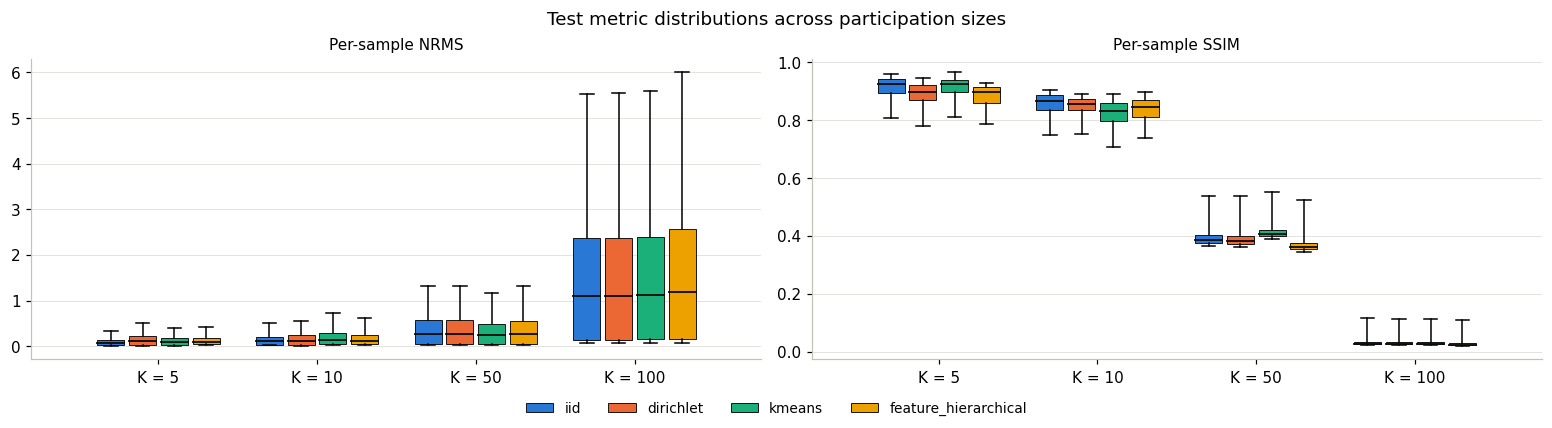

In [12]:
EVAL_METRICS = ['NRMS', 'SSIM']
test_values = {key: {m: per_sample(run, f'Test {m} (dist)') for m in EVAL_METRICS}
               for key, run in test_runs.items()}


def shared_bins(values_by_run, metric, n=30):
    pooled = [v[metric] for v in values_by_run.values() if v[metric].size]
    return np.histogram_bin_edges(np.concatenate(pooled), bins=n) if pooled else None


def grouped_boxplot(ax, data, title):
    # data: {(scheme, K): values}; x = K groups, one box per scheme inside a group.
    width = 0.8 / len(SCHEMES)
    for i, scheme in enumerate(SCHEMES):
        pos, vals = [], []
        for g, K in enumerate(KS):
            v = data.get((scheme, K))
            if v is not None and v.size:
                pos.append(g + (i - (len(SCHEMES) - 1) / 2) * width)
                vals.append(v)
        if not vals:
            continue
        bp = ax.boxplot(vals, positions=pos, widths=width * 0.85, whis=(5, 95), showfliers=False,
                        patch_artist=True, medianprops={'color': INK, 'linewidth': 1.2})
        for box in bp['boxes']:
            box.set(facecolor=SCHEME_COLOR[scheme], edgecolor=INK, linewidth=0.6)
    ax.set_xticks(range(len(KS)))
    ax.set_xticklabels([f'K = {K}' for K in KS])
    ax.set_title(title)


bins = {m: shared_bins(test_values, m) for m in EVAL_METRICS}
for K in KS:
    size_header(K)
    fig, axes = plt.subplots(len(EVAL_METRICS), len(SCHEMES), figsize=(4.3 * len(SCHEMES), 3.0 * len(EVAL_METRICS)),
                             constrained_layout=True, squeeze=False)
    for j, scheme in enumerate(SCHEMES):
        for i, metric in enumerate(EVAL_METRICS):
            ax = axes[i, j]
            vals = test_values.get((scheme, K), {}).get(metric, np.array([]))
            if not vals.size:
                mark_missing(ax, f'{scheme} - {metric}')
                continue
            ax.hist(vals, bins=bins[metric], color=SCHEME_COLOR[scheme], edgecolor='white', linewidth=0.4)
            ax.set_title(f'{scheme} - {metric}')
            ax.set_xlabel(metric)
            ax.set_ylabel('# samples')
            ax.text(0.98, 0.95, f'mean={vals.mean():.4f}\nstd={vals.std():.4f}', transform=ax.transAxes,
                    ha='right', va='top', fontsize=8,
                    bbox={'boxstyle': 'round', 'facecolor': 'white', 'edgecolor': '#e1e0d9'})
    plt.show()
    plt.close(fig)

if test_values:
    fig, axes = plt.subplots(1, len(EVAL_METRICS), figsize=(7 * len(EVAL_METRICS), 3.8), constrained_layout=True)
    for ax, metric in zip(np.atleast_1d(axes), EVAL_METRICS):
        grouped_boxplot(ax, {key: v[metric] for key, v in test_values.items()}, f'Per-sample {metric}')
    scheme_box_legend(fig)
    fig.suptitle('Test metric distributions across participation sizes')
    plt.show()
    plt.close(fig)

## ROC curves

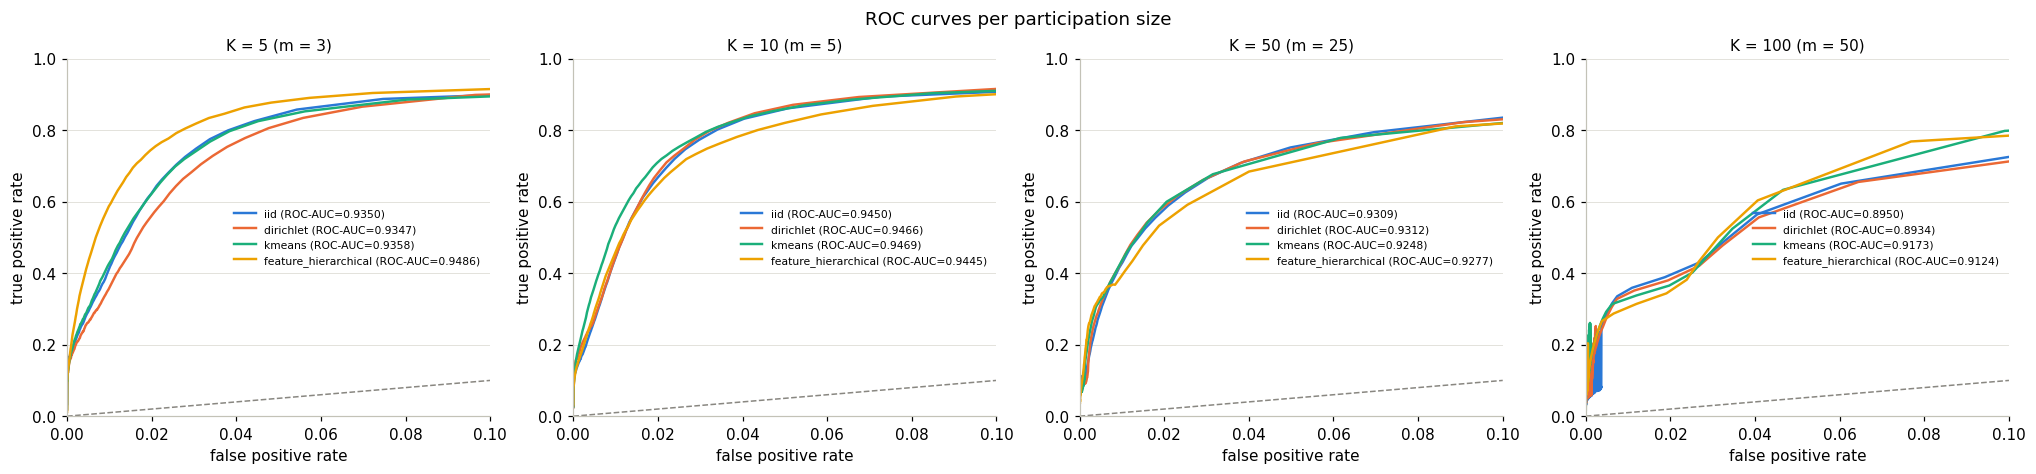

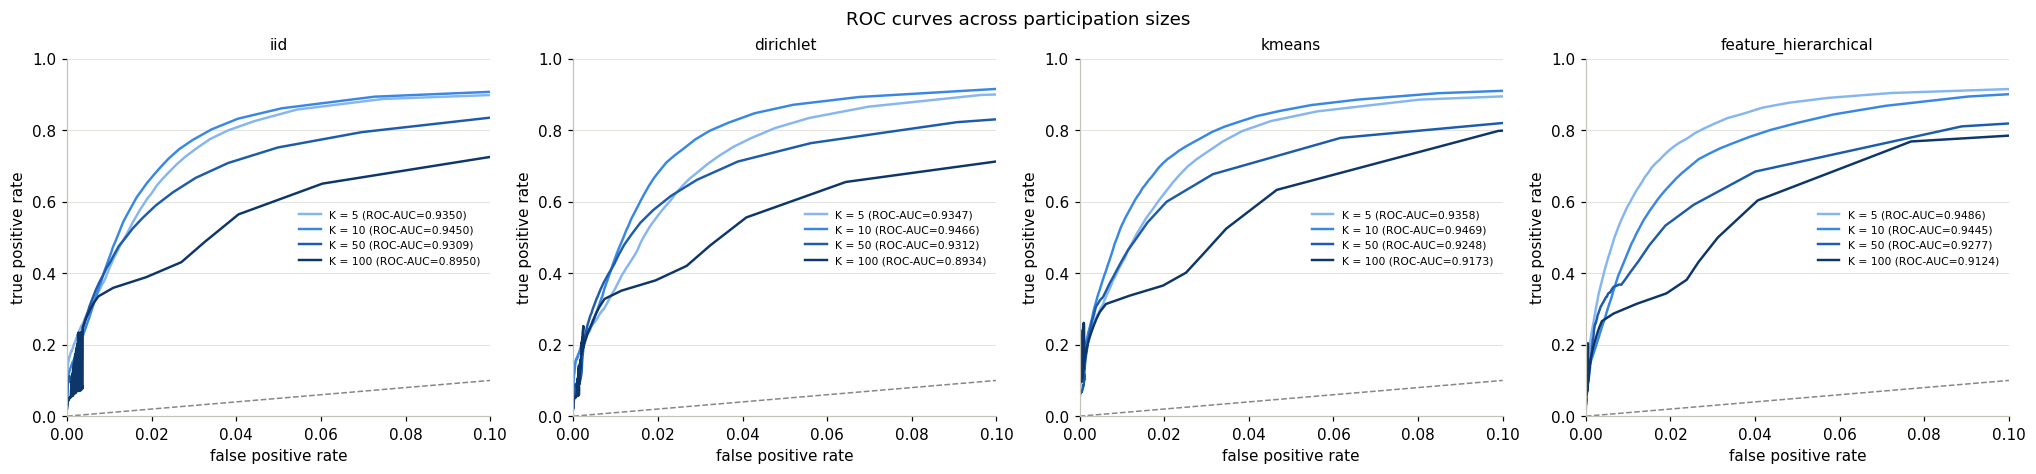

In [14]:
MAX_FPR = 0.10


def roc_pr_curves(run):
    save_path = ((run.get('hparams') or {}).get('evaluation') or {}).get('save_path')
    csv = os.path.join(os.getcwd(), save_path or '', 'roc_prc.csv')
    if not save_path or not os.path.isfile(csv):
        print(f'[{run.hash}] no roc_prc.csv under {save_path} - ROC / PR skipped')
        return None
    roc_auc, pr_auc = roc_prc(save_path)
    tpr, fpr, precision = calculate_all(csv)
    fpr_s, tpr_s = get_sorted_list(fpr, tpr)
    recall_s, precision_s = get_sorted_list(tpr, precision)
    fpr_c, tpr_c = np.r_[fpr_s, 1.0], np.r_[tpr_s, 1.0]
    return {
        'roc_auc': float(roc_auc), 'pr_auc': float(pr_auc),
        'fpr': fpr_c, 'tpr': tpr_c,
        'recall': np.asarray(recall_s), 'precision': np.asarray(precision_s),
        'tpr@fpr5': float(np.interp(0.05, fpr_c, tpr_c)) if fpr_c[0] <= 0.05 else np.nan,
    }


curves = {key: roc_pr_curves(run) for key, run in test_runs.items()}


def plot_roc(ax, c, color, label):
    mask = c['fpr'] <= MAX_FPR
    f = np.r_[c['fpr'][mask], MAX_FPR]
    t = np.r_[c['tpr'][mask], np.interp(MAX_FPR, c['fpr'], c['tpr'])]
    ax.plot(f, t, color=color, label=f"{label} (ROC-AUC={c['roc_auc']:.4f})")


def finish(ax, kind, title):
    if kind == 'roc':
        ax.plot([0, MAX_FPR], [0, MAX_FPR], linestyle='--', color=MUTED, linewidth=1)
        ax.set_xlim(0, MAX_FPR)
        ax.set_xlabel('false positive rate')
        ax.set_ylabel('true positive rate')
    else:
        ax.set_xlim(0, 1)
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
    ax.set_ylim(0, 1)
    ax.set_title(title)
    if ax.lines:
        ax.legend(fontsize=7, loc='center right' if kind == 'roc' else 'lower left')

for kind, plot in [('roc', plot_roc)]:
    if not any(curves.values()):
        break
    # One panel per K, schemes overlaid.
    fig, axes = plt.subplots(1, len(KS), figsize=(4.6 * len(KS), 4.2), constrained_layout=True, squeeze=False)
    for ax, K in zip(axes[0], KS):
        for scheme in SCHEMES:
            c = curves.get((scheme, K))
            if c:
                plot(ax, c, SCHEME_COLOR[scheme], scheme)
        finish(ax, kind, f'K = {K} (m = {round_clients(K)})')
    fig.suptitle(f'{kind.upper()} curves per participation size')
    plt.show()
    plt.close(fig)
    # One panel per scheme, K overlaid.
    fig, axes = plt.subplots(1, len(SCHEMES), figsize=(4.6 * len(SCHEMES), 4.2), constrained_layout=True)
    for ax, scheme in zip(axes, SCHEMES):
        for K in KS:
            c = curves.get((scheme, K))
            if c:
                plot(ax, c, K_COLOR[K], f'K = {K}')
        finish(ax, kind, scheme)
    fig.suptitle(f'{kind.upper()} curves across participation sizes')
    plt.show()
    plt.close(fig)

## Confusion matrices

One 2x2 matrix per test run from `Confusion TP/TN/FP/FN` (summed over the test set, both label and prediction binarised at `evaluation.threshold`), grouped by K.

### K = 5 clients - m = 3 per round (60 % participation)

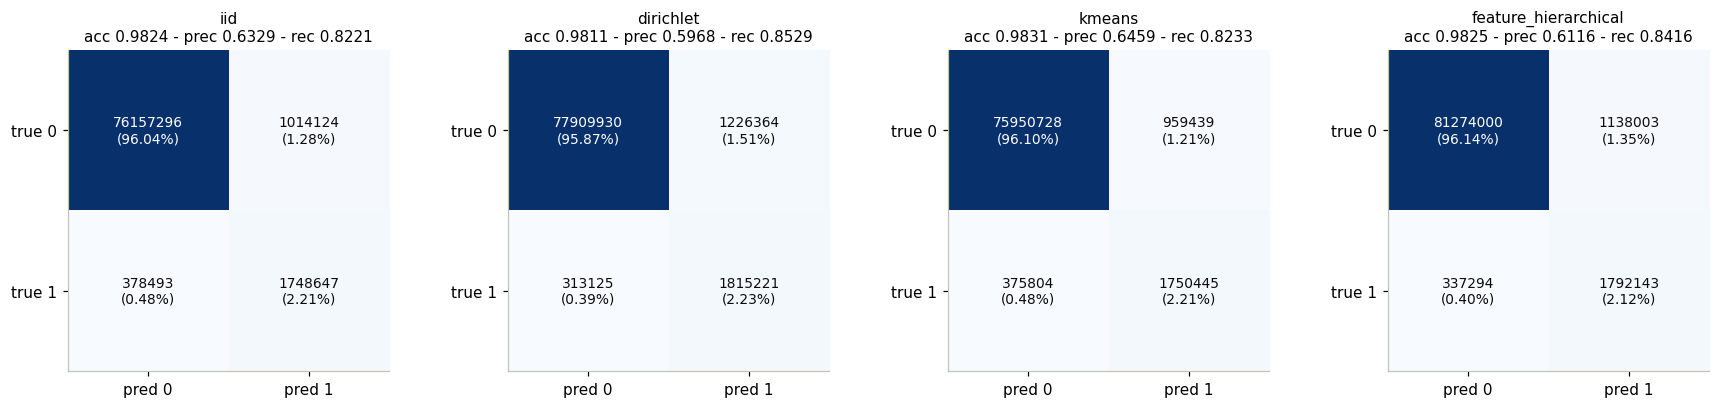

### K = 10 clients - m = 5 per round (50 % participation)

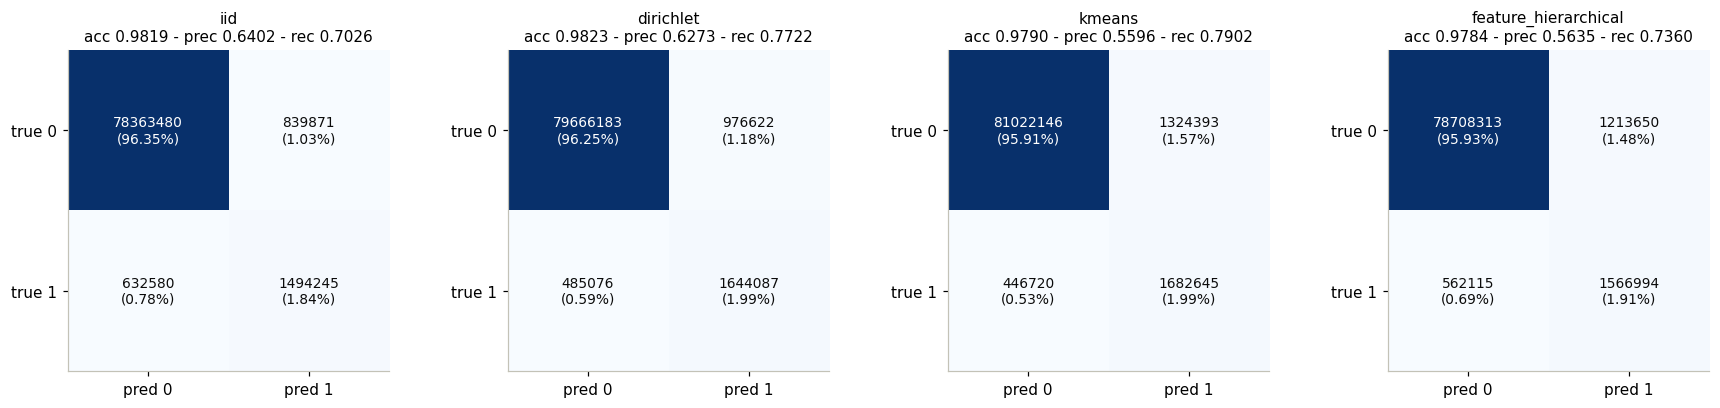

### K = 50 clients - m = 25 per round (50 % participation)

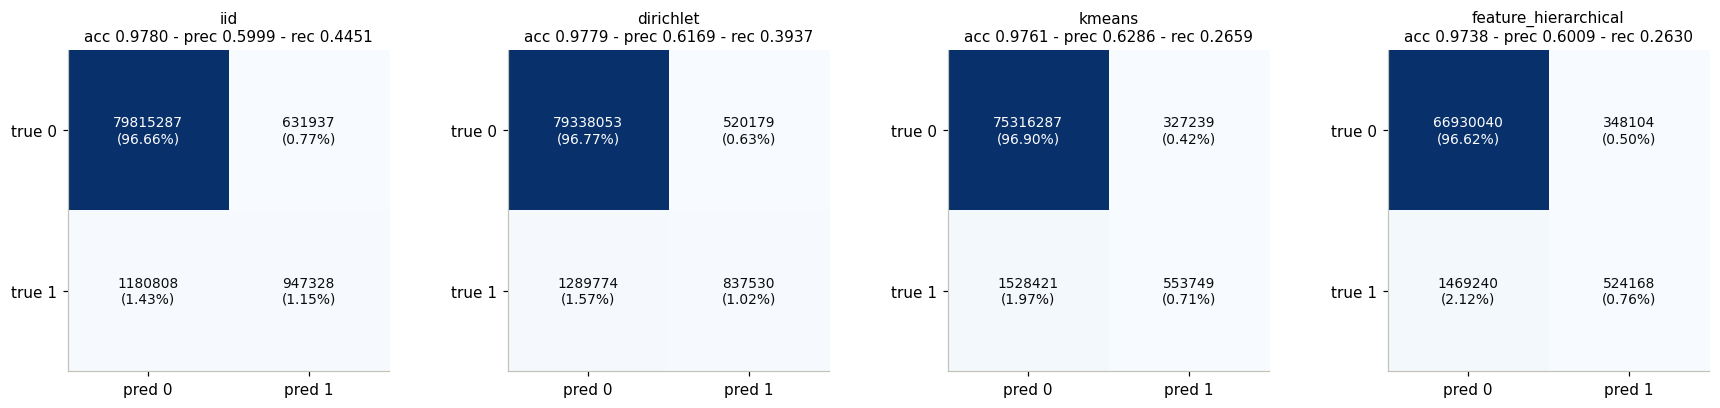

### K = 100 clients - m = 50 per round (50 % participation)

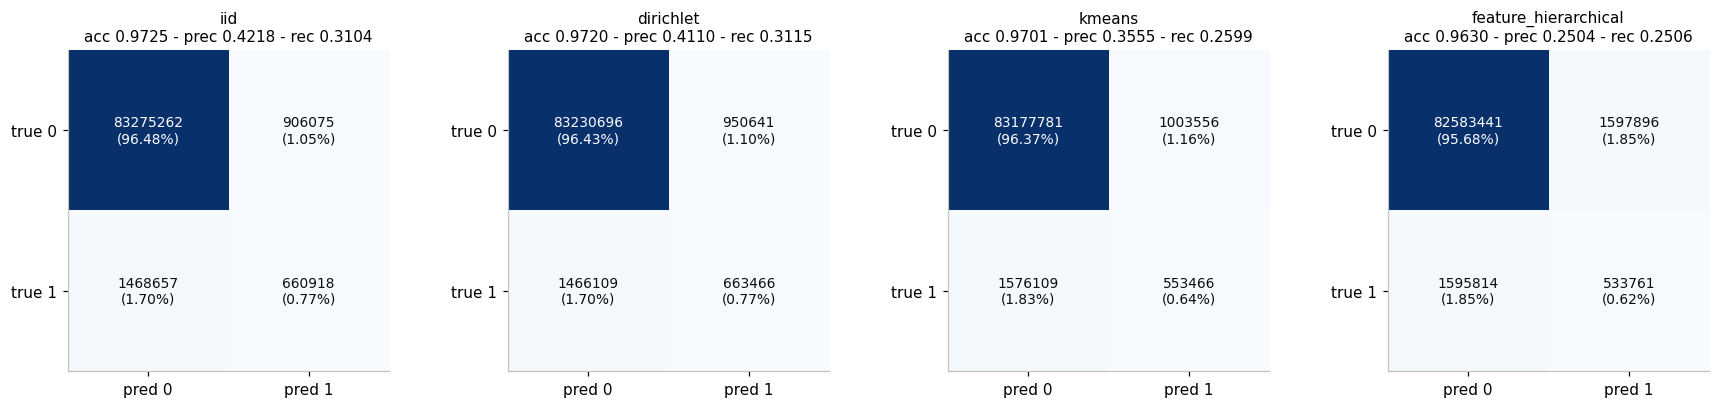

In [15]:
def confusion(run):
    vals = [last_value(run, f'Confusion {k}', {'subset': 'test'}) for k in ('TN', 'FP', 'FN', 'TP')]
    return None if any(np.isnan(v) for v in vals) else np.array(vals, dtype=float).reshape(2, 2)


confusions = {key: confusion(run) for key, run in test_runs.items()}

for K in KS:
    size_header(K)
    fig, axes = plt.subplots(1, len(SCHEMES), figsize=(4.0 * len(SCHEMES), 3.6), constrained_layout=True)
    for ax, scheme in zip(axes, SCHEMES):
        cm = confusions.get((scheme, K))
        if cm is None:
            mark_missing(ax, scheme, 'not run' if (scheme, K) not in test_runs else 'not tracked')
            continue
        (tn, fp), (fn, tp) = cm
        total = cm.sum()
        ax.imshow(cm, cmap='Blues')
        ax.grid(False)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['pred 0', 'pred 1'])
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['true 0', 'true 1'])
        for i in range(2):
            for j in range(2):
                v = cm[i, j]
                ax.text(j, i, f'{int(v)}\n({100 * v / total:.2f}%)', ha='center', va='center', fontsize=9,
                        color='white' if v > cm.max() / 2 else INK)
        precision = tp / (tp + fp) if tp + fp else np.nan
        recall = tp / (tp + fn) if tp + fn else np.nan
        ax.set_title(f'{scheme}\nacc {(tp + tn) / total:.4f} - prec {precision:.4f} - rec {recall:.4f}')
    plt.show()
    plt.close(fig)

## Augmented metrics

test samples  with violations    NRMS  NRMS_nonzero  \
K   scheme                                                                      
5   iid                         3164.0           3164.0  0.1139        0.2218   
    dirichlet                   3164.0           3164.0  0.1603        0.3340   
    kmeans                      3164.0           3164.0  0.1339        0.2775   
    feature_hierarchical        3164.0           3164.0  0.1394        0.2952   
10  iid                         3164.0           3164.0  0.1574        0.2714   
    dirichlet                   3164.0           3164.0  0.1758        0.3068   
    kmeans                      3164.0           3164.0  0.2276        0.4490   
    feature_hierarchical        3164.0           3164.0  0.1886        0.3333   
50  iid                         3164.0           3164.0  0.4170        0.5304   
    dirichlet                   3164.0           3164.0  0.4087        0.5256   
    kmeans                      3164.0           3164.0  0.3663        0.4876   
    feature_hierarchical        3164.0           3164.0  0.4074        0.5786   
100 iid                         3164.0           3164.0  1.6810        1.7144   
    dirichlet                   3164.0           3164.0  1.6834        1.7360   
    kmeans                      3164.0           3164.0  1.7024        1.7629   
    feature_hierarchical        3164.0           3164.0  1.8228        1.8401   

                              MAE  MAE_nonzero  
K   scheme                                      
5   iid                    0.9824       3.0856  
    dirichlet              1.1323       3.4409  
    kmeans                 0.9488       3.1623  
    feature_hierarchical   1.1368       3.5632  
10  iid                    1.2625       3.2962  
    dirichlet              1.3135       3.4177  
    kmeans                 1.5214       4.5591  
    feature_hierarchical   1.4221       4.1487  
50  iid                    3.3379       5.1639  
    dirichlet              3.3036       5.0363  
    kmeans                 3.0714       4.5664  
    feature_hierarchical   3.3286       5.1594  
100 iid                   13.1015      13.7743  
    dirichlet             13.1137      13.9255  
    kmeans                13.2780      14.0015  
    feature_hierarchical  14.2098      14.5948

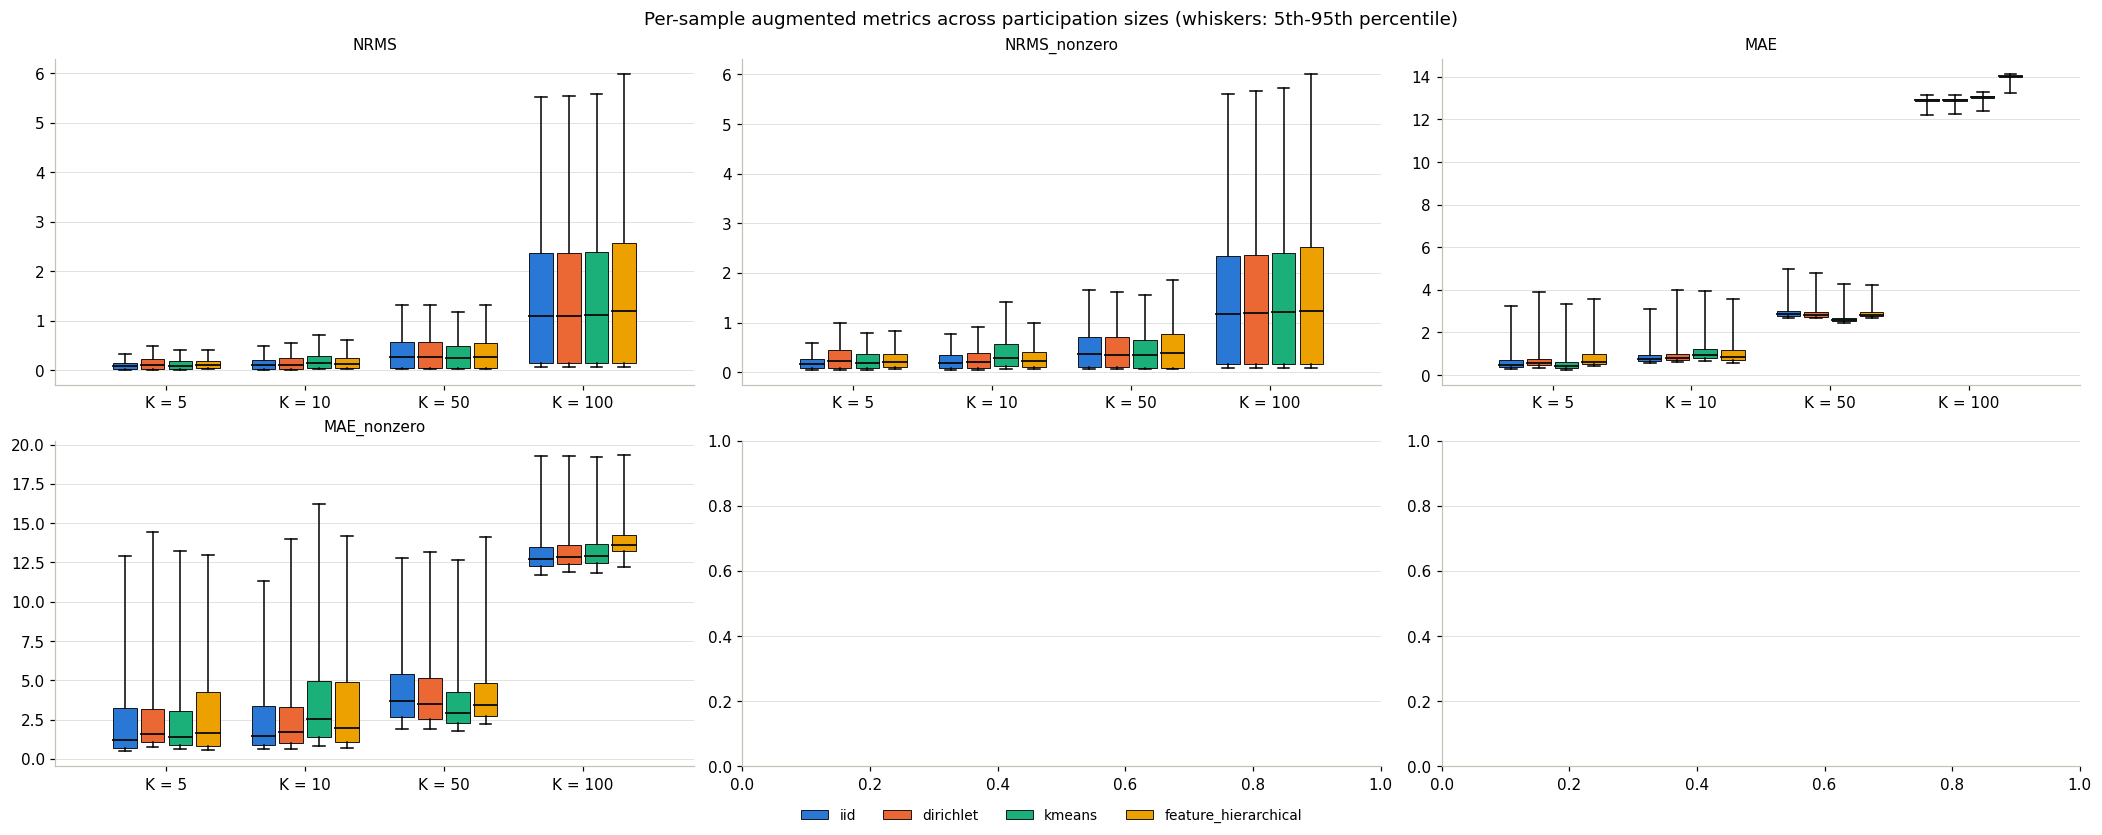

In [16]:
AUG_METRICS = ['NRMS', 'NRMS_nonzero',
               'MAE', 'MAE_nonzero']

aug_rows, aug_values = [], {}
for scheme, K, run in ordered(aug_runs):
    row = {'K': K, 'scheme': scheme,
           'test samples': last_value(run, 'Test samples', {'subset': 'test'}),
           'with violations': last_value(run, 'Test samples with violations', {'subset': 'test'})}
    for metric in AUG_METRICS:
        row[metric] = last_value(run, f'Test Avg {metric}', {'subset': 'test'})
        aug_values[(scheme, K, metric)] = per_sample(run, f'Test {metric} (dist)')
    aug_rows.append(row)

aug_df = pd.DataFrame(aug_rows)
if not aug_df.empty:
    aug_df = aug_df.set_index(['K', 'scheme'])
    display(aug_df.round(4))

    fig, axes = plt.subplots(2, 3, figsize=(19, 7.5), constrained_layout=True)
    for ax, metric in zip(axes.ravel(), AUG_METRICS):
        grouped_boxplot(ax, {(s, K): v for (s, K, m), v in aug_values.items() if m == metric}, metric)
    scheme_box_legend(fig)
    fig.suptitle('Per-sample augmented metrics across participation sizes (whiskers: 5th-95th percentile)')
    plt.show()
    plt.close(fig)

## Final aggregate results

In [17]:
final_rows = []
for K in KS:
    for scheme in SCHEMES:
        key = (scheme, K)
        if key not in test_runs and key not in aug_runs:
            continue
        run = test_runs.get(key)
        c = curves.get(key) or {}
        cm = confusions.get(key)
        vals = test_values.get(key, {})
        row = {
            'K': K,
            'scheme': scheme,
            'ROC-AUC': c.get('roc_auc', np.nan),
            'TPR @ FPR=5%': c.get('tpr@fpr5', np.nan),
            'Accuracy': last_value(run, 'Test Accuracy', {'subset': 'test'}) if run else np.nan,
            'Precision': last_value(run, 'Test Precision', {'subset': 'test'}) if run else np.nan,
            'Recall': cm[1, 1] / cm[1].sum() if cm is not None and cm[1].sum() else np.nan,
            'Avg NRMS': float(vals['NRMS'].mean()) if vals.get('NRMS', np.array([])).size else np.nan,
            'Avg SSIM': float(vals['SSIM'].mean()) if vals.get('SSIM', np.array([])).size else np.nan,
        }
        for metric in ('NRMS_nonzero', 'MAE_nonzero'):
            row[metric] = aug_df.loc[key[::-1], metric] if not aug_df.empty and key[::-1] in aug_df.index else np.nan
        if not loss_df.empty and key[::-1] in loss_df.index:
            row[f'train loss (last {SMOOTH})'] = loss_df.loc[key[::-1], f'mean loss, last {SMOOTH} rounds']
        final_rows.append(row)

final_df = pd.DataFrame(final_rows)
if not final_df.empty:
    final_df = final_df.set_index(['K', 'scheme'])
    display(final_df.round(4))

ROC-AUC  TPR @ FPR=5%  Accuracy  Precision  Recall  \
K   scheme                                                                     
5   iid                    0.9350        0.8434    0.9824     0.6329  0.8221   
    dirichlet              0.9347        0.8136    0.9811     0.5968  0.8529   
    kmeans                 0.9358        0.8368    0.9831     0.6459  0.8233   
    feature_hierarchical   0.9486        0.8793    0.9825     0.6116  0.8416   
10  iid                    0.9450        0.8587    0.9819     0.6402  0.7026   
    dirichlet              0.9466        0.8655    0.9823     0.6273  0.7722   
    kmeans                 0.9469        0.8593    0.9790     0.5596  0.7902   
    feature_hierarchical   0.9445        0.8200    0.9784     0.5635  0.7360   
50  iid                    0.9309        0.7516    0.9780     0.5999  0.4451   
    dirichlet              0.9312        0.7451    0.9779     0.6169  0.3937   
    kmeans                 0.9248        0.7387    0.9761     0.6286  0.2659   
    feature_hierarchical   0.9277        0.7097    0.9738     0.6009  0.2630   
100 iid                    0.8950        0.6054    0.9725     0.4218  0.3104   
    dirichlet              0.8934        0.5941    0.9720     0.4110  0.3115   
    kmeans                 0.9173        0.6434    0.9701     0.3555  0.2599   
    feature_hierarchical   0.9124        0.6459    0.9630     0.2504  0.2506   

                          Avg NRMS  Avg SSIM  NRMS_nonzero  MAE_nonzero  \
K   scheme                                                                
5   iid                     0.1139    0.9077        0.2218       3.0856   
    dirichlet               0.1603    0.8820        0.3340       3.4409   
    kmeans                  0.1339    0.9089        0.2775       3.1623   
    feature_hierarchical    0.1394    0.8790        0.2952       3.5632   
10  iid                     0.1574    0.8523        0.2714       3.2962   
    dirichlet               0.1758    0.8446        0.3068       3.4177   
    kmeans                  0.2276    0.8195        0.4490       4.5591   
    feature_hierarchical    0.1886    0.8348        0.3333       4.1487   
50  iid                     0.4170    0.4048        0.5304       5.1639   
    dirichlet               0.4087    0.4024        0.5256       5.0363   
    kmeans                  0.3663    0.4244        0.4876       4.5664   
    feature_hierarchical    0.4074    0.3821        0.5786       5.1594   
100 iid                     1.6810    0.0400        1.7144      13.7743   
    dirichlet               1.6834    0.0399        1.7360      13.9255   
    kmeans                  1.7024    0.0392        1.7629      14.0015   
    feature_hierarchical    1.8228    0.0356        1.8401      14.5948   

                          train loss (last 10)  
K   scheme                                      
5   iid                                 0.1792  
    dirichlet                           0.1850  
    kmeans                              0.1728  
    feature_hierarchical                0.1742  
10  iid                                 0.2600  
    dirichlet                           0.2460  
    kmeans                              0.2267  
    feature_hierarchical                0.2239  
50  iid                                 0.4312  
    dirichlet                           0.4440  
    kmeans                              0.4453  
    feature_hierarchical                0.4561  
100 iid                                 0.8723  
    dirichlet                           0.8901  
    kmeans                              0.8680  
    feature_hierarchical                0.9323

In [18]:
if not final_df.empty:
    for metric in ('ROC-AUC', 'TPR @ FPR=5%'):
        pivot = final_df[metric].unstack('K').reindex([s for s in SCHEMES if s in final_df.index.get_level_values('scheme')])
        display(Markdown(f'**{metric}** (rows: scheme, columns: K)'))
        display(pivot.round(4))
        if 'iid' in pivot.index:
            display(Markdown(f'**{metric} gap vs iid at the same K**'))
            display(pivot.sub(pivot.loc['iid'], axis=1).drop(index='iid').round(4))

**ROC-AUC** (rows: scheme, columns: K)

K,5,10,50,100
scheme,,,,
iid,0.9350,0.9450,0.9309,0.8950
dirichlet,0.9347,0.9466,0.9312,0.8934
kmeans,0.9358,0.9469,0.9248,0.9173
feature_hierarchical,0.9486,0.9445,0.9277,0.9124


**ROC-AUC gap vs iid at the same K**

K,5,10,50,100
scheme,,,,
dirichlet,-0.0003,0.0017,0.0003,-0.0016
kmeans,0.0008,0.0019,-0.0061,0.0224
feature_hierarchical,0.0136,-0.0004,-0.0032,0.0174


**TPR @ FPR=5%** (rows: scheme, columns: K)

K,5,10,50,100
scheme,,,,
iid,0.8434,0.8587,0.7516,0.6054
dirichlet,0.8136,0.8655,0.7451,0.5941
kmeans,0.8368,0.8593,0.7387,0.6434
feature_hierarchical,0.8793,0.8200,0.7097,0.6459


**TPR @ FPR=5% gap vs iid at the same K**

K,5,10,50,100
scheme,,,,
dirichlet,-0.0298,0.0068,-0.0065,-0.0113
kmeans,-0.0065,0.0005,-0.0129,0.0380
feature_hierarchical,0.0359,-0.0387,-0.0420,0.0405


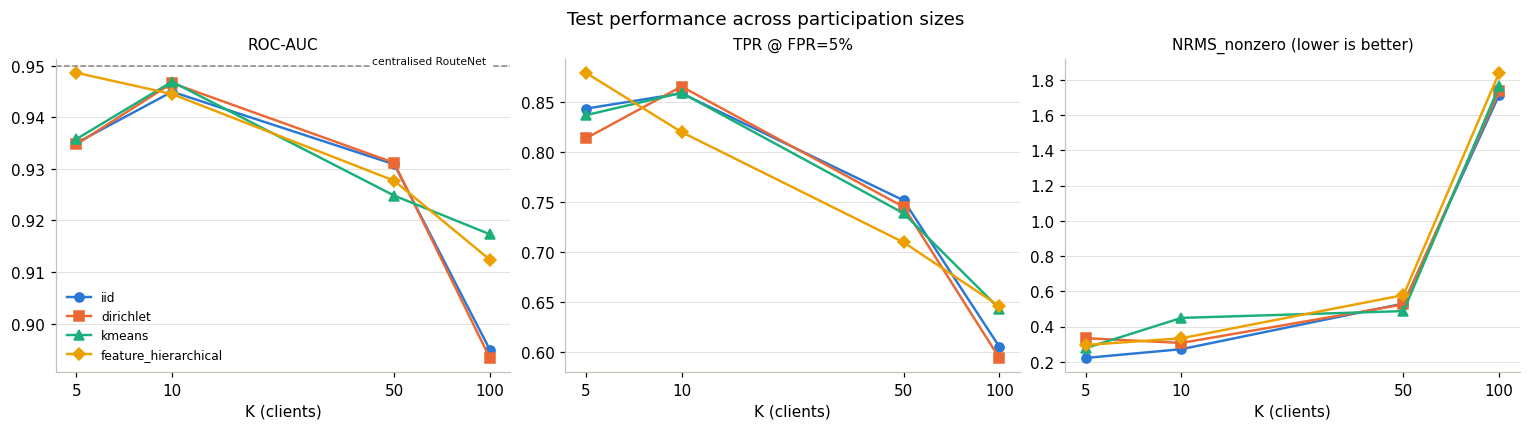

In [20]:
# Headline cross-size comparison.  Dashed: centralised RouteNet baseline
# (TCAD 2023) for reference, not a run of this sweep.
BASELINE = {'ROC-AUC': 0.95, 'PR-AUC': 0.63}

if not final_df.empty:
    panels = ['ROC-AUC', 'TPR @ FPR=5%', 'NRMS_nonzero']
    fig, axes = plt.subplots(1, len(panels), figsize=(4.6 * len(panels), 3.8), constrained_layout=True)
    for ax, metric in zip(axes, panels):
        for scheme in SCHEMES:
            if scheme not in final_df.index.get_level_values('scheme'):
                continue
            sub = final_df.xs(scheme, level='scheme')[metric].dropna()
            ax.plot(sub.index, sub.values, color=SCHEME_COLOR[scheme], marker=SCHEME_MARKER[scheme], label=scheme)
        if metric in BASELINE:
            ax.axhline(BASELINE[metric], color=MUTED, linestyle='--', linewidth=1)
            ax.text(KS[-1], BASELINE[metric], 'centralised RouteNet ', ha='right', va='bottom', fontsize=7,
                    color=INK, bbox={'facecolor': 'white', 'edgecolor': 'none', 'pad': 1})
        ax.set_title(metric + (' (lower is better)' if metric == 'NRMS_nonzero' else ''))
        log_k_axis(ax)
    scheme_legend(axes[0])
    fig.suptitle('Test performance across participation sizes')
    plt.show()
    plt.close(fig)